# Step-by-step MCMC processing of one configurable sensor trace

This notebook follows the single-measurement calculation behind `01_process_raw_data.ipynb`, but makes every numerical step visible. The editable configuration in the next cell controls the ideal H–M source, Stage-3 sensor simulation, sampler, worked window, grid, and comparison windows.

The ideal source is used only for evaluation. The fitting code receives the final simulated sensor measurements and the configured sensor precision. Change the configuration cell, then run all cells from the top.


In [85]:
import contextlib
import io
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from IPython.display import display

CWD = pathlib.Path.cwd().resolve()
for candidate in [CWD, *CWD.parents]:
    if (candidate / "pyproject.toml").exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the repository root containing pyproject.toml.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from synthetic import Generator, Simulate_Sensor
from soilgasflux_fcs import FCS, HM_model, Pareto
from soilgasflux_fcs.hm_model import MCMC_WALKERS
from soilgasflux_fcs.mcmc import BURN_IN_FRACTION, MCMC, THIN
from soilgasflux_fcs.models import (
    calculate_saturated_vapor_pressure,
    hm_model,
    hm_model_dcdt,
    mole_fraction_water_vapor,
    soilgasflux,
)

sns.set_theme(style="ticks", context="notebook")

EXAMPLE_DIR = REPO_ROOT / "notebooks" / "processing" / "step-by-step example"
FIGURE_DIR = EXAMPLE_DIR / "figures"
RAW_CSV = EXAMPLE_DIR / "toy_raw_data.csv"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# EDITABLE CONFIGURATION: source, duration, sensor, seeds, sampler, and windows.
# -----------------------------------------------------------------------------
SCENARIO_ID = "convex_medium"
N_SAMPLES = 180                  # At 1 Hz, this is also the duration in samples.
SAMPLE_INTERVAL_S = 1            # The current simulator requires exactly 1 Hz.
TARGET_DELTA_PPM = 110.0

TRUTH = {
    "c0": 430.0,
    "alpha": 0.003,
    "t0": 0.0,
}

ENVIRONMENT = {
    "pressure_pa": 99_000.0,
    "temperature_c": 20.0,
    "humidity_percent": 70.0,
}
CHAMBER = {
    "area_cm2": float(np.pi * 20**2 / 4),
    "volume_cm3": float(np.pi * 20**2 * 20 / 4),
}
SENSOR_SETTINGS = {
    "response_time": 10,
    "gas_analyzer_volume": 120,
    "sensor_accuracy": 1.5,
    "sensor_precision": 1.5,
    "pump_volume": 40,
    "pump_rate": 120,
    "additional_volume": 80,
    "with_diffusion": True,
    "with_advection": True,
}

SENSOR_SEED = 251296
MCMC_SEED = 251296
N_MCMC_STEPS = 2000

EXAMPLE_DEADBAND = 20
EXAMPLE_CUTOFF = 80              # Exclusive row position.

GRID_WINDOW_WALK = 10
GRID_MIN_WINDOW_SIZE = 60
GRID_MIN_DEADBAND = 0
GRID_MAX_DEADBAND = 60           # Exclusive, matching numpy.arange/FCS.
GRID_MAX_CUTOFF = None           # None uses the final elapsed-time coordinate.

ARBITRARY_CONFIGS = [
    # {"label": "Arbitrary 1", "deadband": 0, "cutoff": 60, "color": "#4c78a8", "marker": "s"},
    {"label": "Arbitrary 2", "deadband": 20, "cutoff": 80, "color": "#f58518", "marker": "^"},
    # {"label": "Arbitrary 3", "deadband": 20, "cutoff": 170, "color": "#54a24b", "marker": "o"},
]

# -----------------------------------------------------------------------------
# Early validation: fail only for physically or structurally unusable settings.
# -----------------------------------------------------------------------------
def require_integer(name, value, minimum=None):
    if isinstance(value, bool) or not np.isfinite(value) or int(value) != value:
        raise ValueError(f"{name} must be a finite integer; received {value!r}.")
    value = int(value)
    if minimum is not None and value < minimum:
        raise ValueError(f"{name} must be at least {minimum}; received {value}.")
    return value


N_SAMPLES = require_integer("N_SAMPLES", N_SAMPLES, minimum=10)
SAMPLE_INTERVAL_S = require_integer("SAMPLE_INTERVAL_S", SAMPLE_INTERVAL_S, minimum=1)
if SAMPLE_INTERVAL_S != 1:
    raise ValueError(
        "SAMPLE_INTERVAL_S must be 1 because Simulate_Sensor currently requires 1 Hz sampling."
    )

source_values = np.array(
    [TRUTH["c0"], TRUTH["alpha"], TRUTH["t0"], TARGET_DELTA_PPM], dtype=float
)
if not np.isfinite(source_values).all():
    raise ValueError("C0, alpha, t0, and TARGET_DELTA_PPM must all be finite.")
if TRUTH["alpha"] <= 0:
    raise ValueError(f"TRUTH['alpha'] must be positive; received {TRUTH['alpha']!r}.")

positive_sensor_fields = [
    "response_time", "gas_analyzer_volume", "sensor_precision",
    "pump_volume", "pump_rate", "additional_volume",
]
for field in positive_sensor_fields:
    value = SENSOR_SETTINGS[field]
    if not np.isfinite(value) or value <= 0:
        raise ValueError(f"SENSOR_SETTINGS['{field}'] must be finite and positive; received {value!r}.")
SENSOR_SETTINGS["response_time"] = require_integer(
    "SENSOR_SETTINGS['response_time']", SENSOR_SETTINGS["response_time"], minimum=1
)
for field in ["area_cm2", "volume_cm3"]:
    if not np.isfinite(CHAMBER[field]) or CHAMBER[field] <= 0:
        raise ValueError(f"CHAMBER['{field}'] must be finite and positive.")

SENSOR_PRECISION_PPM = float(SENSOR_SETTINGS["sensor_precision"])
N_MCMC_STEPS = require_integer("N_MCMC_STEPS", N_MCMC_STEPS, minimum=1)
burn_step_preview = int(N_MCMC_STEPS * BURN_IN_FRACTION)
retained_step_preview = np.arange(burn_step_preview, N_MCMC_STEPS, THIN)
if retained_step_preview.size < 1:
    raise ValueError(
        "N_MCMC_STEPS leaves no state after the configured burn-in and thinning. "
        f"Increase it above {N_MCMC_STEPS}."
    )

EXAMPLE_DEADBAND = require_integer("EXAMPLE_DEADBAND", EXAMPLE_DEADBAND, minimum=0)
EXAMPLE_CUTOFF = require_integer("EXAMPLE_CUTOFF", EXAMPLE_CUTOFF, minimum=1)
if EXAMPLE_CUTOFF > N_SAMPLES:
    raise ValueError(
        f"EXAMPLE_CUTOFF={EXAMPLE_CUTOFF} is outside the {N_SAMPLES}-sample trace."
    )
if EXAMPLE_CUTOFF - EXAMPLE_DEADBAND < 4:
    raise ValueError(
        "The worked window must contain at least four observations: "
        "EXAMPLE_CUTOFF - EXAMPLE_DEADBAND >= 4."
    )

GRID_WINDOW_WALK = require_integer("GRID_WINDOW_WALK", GRID_WINDOW_WALK, minimum=1)
GRID_MIN_WINDOW_SIZE = require_integer("GRID_MIN_WINDOW_SIZE", GRID_MIN_WINDOW_SIZE, minimum=4)
GRID_MIN_DEADBAND = require_integer("GRID_MIN_DEADBAND", GRID_MIN_DEADBAND, minimum=0)
GRID_MAX_DEADBAND = require_integer("GRID_MAX_DEADBAND", GRID_MAX_DEADBAND, minimum=1)
if GRID_MAX_DEADBAND <= GRID_MIN_DEADBAND:
    raise ValueError("GRID_MAX_DEADBAND must be greater than GRID_MIN_DEADBAND.")
if GRID_MAX_DEADBAND > N_SAMPLES:
    raise ValueError("GRID_MAX_DEADBAND cannot exceed N_SAMPLES.")
if GRID_MAX_CUTOFF is not None:
    GRID_MAX_CUTOFF = require_integer("GRID_MAX_CUTOFF", GRID_MAX_CUTOFF, minimum=1)
    if GRID_MAX_CUTOFF > N_SAMPLES:
        raise ValueError("GRID_MAX_CUTOFF cannot exceed N_SAMPLES when supplied.")

grid_upper_preview = N_SAMPLES - 1 if GRID_MAX_CUTOFF is None else GRID_MAX_CUTOFF
deadband_preview = np.arange(
    GRID_MIN_DEADBAND, GRID_MAX_DEADBAND, GRID_WINDOW_WALK, dtype=int
)
cutoff_preview = np.arange(
    GRID_MIN_DEADBAND + GRID_MIN_WINDOW_SIZE,
    int(grid_upper_preview),
    GRID_WINDOW_WALK,
    dtype=int,
)
if deadband_preview.size == 0 or cutoff_preview.size == 0:
    raise ValueError("The configured grid does not generate any deadband/cutoff coordinates.")
candidate_preview = (
    cutoff_preview[:, None] - deadband_preview[None, :] >= GRID_MIN_WINDOW_SIZE
)
if not candidate_preview.any():
    raise ValueError(
        "The configured grid has no window satisfying cutoff - deadband >= GRID_MIN_WINDOW_SIZE."
    )

for index, config in enumerate(ARBITRARY_CONFIGS, start=1):
    missing = {"label", "deadband", "cutoff", "color", "marker"} - set(config)
    if missing:
        raise ValueError(f"ARBITRARY_CONFIGS entry {index} is missing {sorted(missing)}.")
    config["deadband"] = require_integer(
        f"ARBITRARY_CONFIGS[{index - 1}]['deadband']", config["deadband"], minimum=0
    )
    config["cutoff"] = require_integer(
        f"ARBITRARY_CONFIGS[{index - 1}]['cutoff']", config["cutoff"], minimum=1
    )

duration_s = (N_SAMPLES - 1) * SAMPLE_INTERVAL_S
TRUTH["cx"] = float(
    TRUTH["c0"]
    + TARGET_DELTA_PPM / (1 - np.exp(-TRUTH["alpha"] * duration_s))
)
if not np.isfinite(TRUTH["cx"]):
    raise ValueError("The configured source produced a non-finite Cx value.")

MEASUREMENT_ID = f"toy_sensor_{SENSOR_PRECISION_PPM:g}ppm".replace(".", "p")

configuration_summary = pd.DataFrame(
    {
        "setting": [
            "target change", "samples", "sampling interval", "sensor response time",
            "sensor precision", "sensor seed", "MCMC seed", "MCMC steps",
            "worked window", "grid walk", "minimum grid window",
            "grid deadband range", "optional maximum cutoff",
        ],
        "value": [
            f"{TARGET_DELTA_PPM:g} ppm", N_SAMPLES, f"{SAMPLE_INTERVAL_S} s",
            f"{SENSOR_SETTINGS['response_time']} s", f"{SENSOR_PRECISION_PPM:g} ppm",
            SENSOR_SEED, MCMC_SEED, N_MCMC_STEPS,
            f"DB={EXAMPLE_DEADBAND}, CO={EXAMPLE_CUTOFF}", GRID_WINDOW_WALK,
            GRID_MIN_WINDOW_SIZE, f"[{GRID_MIN_DEADBAND}, {GRID_MAX_DEADBAND})",
            "data maximum" if GRID_MAX_CUTOFF is None else GRID_MAX_CUTOFF,
        ],
    }
)
display(configuration_summary)
print(f"Repository root: {REPO_ROOT}")
print(
    f"Sampler: {MCMC_WALKERS} walkers × {N_MCMC_STEPS} steps; "
    f"burn={BURN_IN_FRACTION:.0%}; thin={THIN}; "
    f"retained step positions per walker={retained_step_preview.size}"
)


,setting,value
0,target change,110 ppm
1,samples,180
2,sampling interval,1 s
3,sensor response time,10 s
4,sensor precision,1.5 ppm
5,sensor seed,251296
6,MCMC seed,251296
7,MCMC steps,2000
8,worked window,"DB=20, CO=80"
9,grid walk,10


Repository root: /Users/alexnaokiasatokobayashi/git/soilgasflux_fcs
Sampler: 20 walkers × 2000 steps; burn=80%; thin=15; retained step positions per walker=27


## 1. Create the ideal source and configurable Stage-3 sensor measurement

The ideal concentration is generated with `Generator.generate_base`:

\[
C(t)=C_x+(C_0-C_x)\exp[-\alpha(t-t_0)],
\qquad
\frac{dC}{dt}=\alpha(C_x-C_0)\exp[-\alpha(t-t_0)].
\]

The analytic derivative is injected into `Simulate_Sensor`, which models stochastic diffusion/advection and gas exchange among the chamber, internal pump, additional volume, and analyzer. Let \(g_i\) be the analyzer concentration before its response filter and \(\Delta g_i=g_i-g_{i-1}\). For configured integer response time \(r\), the simulator's linear kernel distributes each increment uniformly:

\[
s_{i,k}=\begin{cases}
\Delta g_i/r,&i\le k<i+r,\\
0,&\text{otherwise},
\end{cases}
\qquad
y_k=g_0+\sum_{j=0}^{k}\sum_i s_{i,j}+\epsilon_k,
\qquad
\epsilon_k\sim\mathcal N(0,\sigma_{sensor}^2).
\]

All source, hardware, response-time, precision, and seed values come from the configuration cell. Sensor accuracy is stored as simulator metadata but is not applied by the current simulator.


In [86]:
elapsed_s = np.arange(N_SAMPLES, dtype=int) * SAMPLE_INTERVAL_S

generator = Generator(total_time=N_SAMPLES, c0=TRUTH["c0"])
ideal_config = generator.generate_base(
    alpha=TRUTH["alpha"],
    cs=TRUTH["cx"],
    c0=TRUTH["c0"],
    t0=TRUTH["t0"],
    total_time=N_SAMPLES,
    deadband=0,
    background_band=0,
    unmixed_phase=0,
    unmixed_disturbance_intensity=0,
    mixed_phase_disturbance=0,
    disturbance_intensity=0,
    disturbance_starting_point=0,
    add_noise=False,
    noise_intensity=0,
    curvature="convex",
    noise_type=None,
)
ideal_co2_ppm = np.asarray(ideal_config["final_value"], dtype=float)
source_dcdt_ppm_s = hm_model_dcdt(
    t0=TRUTH["t0"],
    c0=TRUTH["c0"],
    a=TRUTH["alpha"],
    cx=TRUTH["cx"],
    t=elapsed_s,
)


def run_stage3_lowcost_sensor(seed):
    """Repeat the Stage-3 call sequence without leaking NumPy's global RNG state."""
    stage3_simulator = Simulate_Sensor(
        alpha=TRUTH["alpha"],
        cs=TRUTH["cx"],
        t0=TRUTH["t0"],
        c0=TRUTH["c0"],
        total_time=N_SAMPLES,
        dt=SAMPLE_INTERVAL_S,
    )
    original_random_state = np.random.get_state()
    np.random.seed(seed)
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            stage3_simulator.chamber_settings(
                area=CHAMBER["area_cm2"],
                chamber_volume=CHAMBER["volume_cm3"],
            )
            stage3_simulator.gasAnalyzer_settings(
                response_time=SENSOR_SETTINGS["response_time"],
                gasAnalyzer_volume=SENSOR_SETTINGS["gas_analyzer_volume"],
                sensor_accuracy=SENSOR_SETTINGS["sensor_accuracy"],
                sensor_precision=SENSOR_SETTINGS["sensor_precision"],
            )
            stage3_simulator.internal_pump_settings(
                pump_volume=SENSOR_SETTINGS["pump_volume"],
                pump_rate=SENSOR_SETTINGS["pump_rate"],
            )
            stage3_simulator.additional_settings(volume=SENSOR_SETTINGS["additional_volume"])
            stage3_measurement = stage3_simulator.run_simulation(
                source_ppm=source_dcdt_ppm_s,
                with_diffusion=SENSOR_SETTINGS["with_diffusion"],
                with_advection=SENSOR_SETTINGS["with_advection"],
                verbose=False,
            )
    finally:
        np.random.set_state(original_random_state)
    return stage3_simulator, np.asarray(stage3_measurement, dtype=float)


simulator, measured_co2_ppm = run_stage3_lowcost_sensor(SENSOR_SEED)
_, deterministic_rerun_co2_ppm = run_stage3_lowcost_sensor(SENSOR_SEED)
assert np.array_equal(measured_co2_ppm, deterministic_rerun_co2_ppm)

internal_analyzer_raw = np.asarray(
    simulator.elements["gas_analyzer"]["measured_concentration"], dtype=float
).reshape(-1)
if not np.isfinite(internal_analyzer_raw).any():
    raise RuntimeError("The simulator returned no finite internal-analyzer values.")
internal_analyzer_co2_ppm = (
    pd.Series(internal_analyzer_raw).ffill().bfill().to_numpy(dtype=float)
)

response_random_state = np.random.get_state()
try:
    response_only_co2_ppm = simulator.sensor_measurement(
        gasAnalyzer_data=internal_analyzer_co2_ppm,
        time_data=simulator.time,
        responseTime=SENSOR_SETTINGS["response_time"],
        responseType="linear",
        samplingFrequency=1,
        sensor_precision=0,
    )
finally:
    np.random.set_state(response_random_state)
response_only_co2_ppm = np.asarray(response_only_co2_ppm, dtype=float)

for name, values in {
    "ideal source": ideal_co2_ppm,
    "source derivative": source_dcdt_ppm_s,
    "internal analyzer": internal_analyzer_co2_ppm,
    "response-only sensor": response_only_co2_ppm,
    "final sensor": measured_co2_ppm,
}.items():
    if len(values) != N_SAMPLES or not np.isfinite(values).all():
        raise RuntimeError(f"{name} must contain {N_SAMPLES} finite samples.")

start_time = pd.Timestamp("2026-08-03 12:00:00")
raw_created = pd.DataFrame(
    {
        "measurement_id": MEASUREMENT_ID,
        "timestamp_utc": start_time + pd.to_timedelta(elapsed_s, unit="s"),
        "elapsed_s": elapsed_s,
        "co2_ppm": measured_co2_ppm,
        "temperature_c": ENVIRONMENT["temperature_c"],
        "relative_humidity_percent": ENVIRONMENT["humidity_percent"],
        "pressure_pa": ENVIRONMENT["pressure_pa"],
        "sensor_response_time_s": SENSOR_SETTINGS["response_time"],
        "sensor_precision_ppm": SENSOR_PRECISION_PPM,
    }
)
raw_created.to_csv(RAW_CSV, index=False, float_format="%.17g")

raw = pd.read_csv(RAW_CSV, float_precision="round_trip")
canonical = pd.DataFrame(
    {
        "datetime": pd.to_datetime(raw["timestamp_utc"], errors="raise"),
        "id": raw["measurement_id"].astype(str),
        "timedelta": pd.to_numeric(raw["elapsed_s"], errors="raise"),
        "k30_co2": pd.to_numeric(raw["co2_ppm"], errors="raise"),
        "si_temperature": pd.to_numeric(raw["temperature_c"], errors="raise"),
        "si_humidity": pd.to_numeric(raw["relative_humidity_percent"], errors="raise"),
        "bmp_pressure": pd.to_numeric(raw["pressure_pa"], errors="raise"),
    }
)
CANONICAL_COLUMNS = [
    "datetime", "id", "timedelta", "k30_co2",
    "si_temperature", "si_humidity", "bmp_pressure",
]

assert list(canonical.columns) == CANONICAL_COLUMNS
assert len(canonical) == N_SAMPLES
assert not canonical.isna().any().any()
assert canonical["id"].nunique() == 1
assert np.array_equal(canonical["timedelta"].to_numpy(), elapsed_s)
assert np.all(
    canonical["datetime"].diff().dropna().dt.total_seconds().to_numpy()
    == SAMPLE_INTERVAL_S
)
assert raw["sensor_response_time_s"].eq(SENSOR_SETTINGS["response_time"]).all()
assert raw["sensor_precision_ppm"].eq(SENSOR_PRECISION_PPM).all()
assert np.array_equal(raw["co2_ppm"].to_numpy(), measured_co2_ppm)

settings_table = pd.DataFrame(
    {"setting": list(SENSOR_SETTINGS), "value": list(SENSOR_SETTINGS.values())}
)
mapping = pd.DataFrame(
    {
        "raw column": [
            "timestamp_utc", "measurement_id", "elapsed_s", "co2_ppm",
            "temperature_c", "relative_humidity_percent", "pressure_pa",
        ],
        "canonical column": CANONICAL_COLUMNS,
        "unit": ["datetime", "text", "s", "ppm", "°C", "%", "Pa"],
    }
)
response_lag_max_ppm = float(np.max(np.abs(response_only_co2_ppm - ideal_co2_ppm)))
display(settings_table)
display(mapping)
display(canonical.head())
print(f"Configured Cx: {TRUTH['cx']:.6g} ppm")
print(f"Final sensor value: {measured_co2_ppm[-1]:.6g} ppm")
print(f"Maximum response-only difference from ideal: {response_lag_max_ppm:.6g} ppm")
print(f"Saved and exactly reloaded {len(raw)} sensor rows from {RAW_CSV.name}.")


,setting,value
0,response_time,10
1,gas_analyzer_volume,120
2,sensor_accuracy,1.5
3,sensor_precision,1.5
4,pump_volume,40
5,pump_rate,120
6,additional_volume,80
7,with_diffusion,True
8,with_advection,True


,raw column,canonical column,unit
0,timestamp_utc,datetime,datetime
1,measurement_id,id,text
2,elapsed_s,timedelta,s
3,co2_ppm,k30_co2,ppm
4,temperature_c,si_temperature,°C
5,relative_humidity_percent,si_humidity,%
6,pressure_pa,bmp_pressure,Pa


,datetime,id,timedelta,k30_co2,si_temperature,si_humidity,bmp_pressure
0,2026-08-03 12:00:00,toy_sensor_1p5ppm,0,428.981837,20,70,99000
1,2026-08-03 12:00:01,toy_sensor_1p5ppm,1,429.225192,20,70,99000
2,2026-08-03 12:00:02,toy_sensor_1p5ppm,2,432.228685,20,70,99000
3,2026-08-03 12:00:03,toy_sensor_1p5ppm,3,431.406589,20,70,99000
4,2026-08-03 12:00:04,toy_sensor_1p5ppm,4,429.157868,20,70,99000


Configured Cx: 694.741 ppm
Final sensor value: 538.352 ppm
Maximum response-only difference from ideal: 6.8352 ppm
Saved and exactly reloaded 180 sensor rows from toy_raw_data.csv.


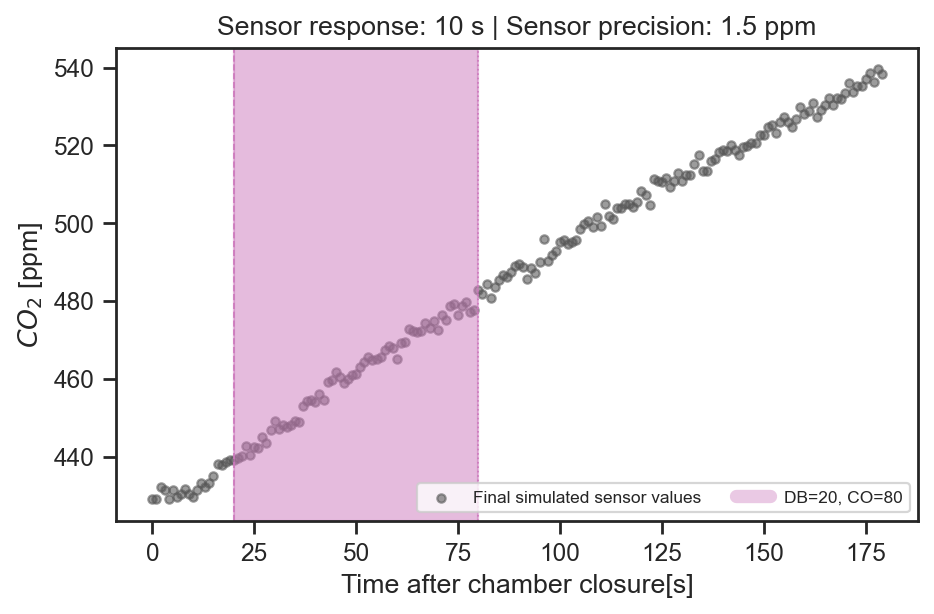

Saved figures/01_raw_trace_and_windows.png


In [91]:
raw_figure_path = FIGURE_DIR / "01_raw_trace_and_windows.png"
fig, ax = plt.subplots(figsize=(6, 4), dpi=160)
# ax.plot(elapsed_s, ideal_co2_ppm, color="black", linewidth=2.2, label="Ideal H–M source")
# ax.plot(
#     elapsed_s, internal_analyzer_co2_ppm, color="#eeca3b", linewidth=1.4, alpha=0.9,
#     label="Internal analyzer before response filter",
# )
# ax.plot(
#     elapsed_s, response_only_co2_ppm, color="#4c78a8", linewidth=2.0,
#     label=f"{SENSOR_SETTINGS['response_time']} s response, no precision noise",
# )
# ax.fill_between(
#     elapsed_s,
#     response_only_co2_ppm - SENSOR_PRECISION_PPM,
#     response_only_co2_ppm + SENSOR_PRECISION_PPM,
#     color="#4c78a8",
#     alpha=0.12,
#     label=rf"Response-only ±{SENSOR_PRECISION_PPM:g} ppm precision",
# )
ax.scatter(
    canonical["timedelta"], canonical["k30_co2"], s=14, color="#555555", alpha=0.58,
    label="Final simulated sensor values",
)
configured_window_color = window_histogram_palette[4]  # purple

raw_window_configs = []
for config in ARBITRARY_CONFIGS:
    if 0 <= config["deadband"] < config["cutoff"] <= N_SAMPLES:
        raw_window_configs.append(config)
        ax.axvspan(config["deadband"], config["cutoff"], color=configured_window_color, alpha=0.5)
        ax.axvline(config["deadband"], color=configured_window_color, linestyle="--", linewidth=0.75)
        ax.axvline(config["cutoff"], color=configured_window_color, linestyle=":", linewidth=0.75)
        ax.plot(
            [], [], color=configured_window_color, linewidth=6, alpha=0.4,
            label=f"DB={config['deadband']}, CO={config['cutoff']}",
        )
    else:
        print(
            f"Skipping raw-window overlay for {config['label']}: "
            f"DB={config['deadband']}, CO={config['cutoff']} is outside the data."
        )

ax.set(
    xlabel="Time after chamber closure[s]",
    ylabel=r"$CO_2$ [ppm]",
    title=(
        # f"Configured sensor trace: target change {TARGET_DELTA_PPM:g} ppm, "
        f"Sensor response: {SENSOR_SETTINGS['response_time']} s | Sensor precision: {SENSOR_PRECISION_PPM} ppm"
        
    ),
)
ax.legend(ncols=2, fontsize=7.8, frameon=True)
fig.tight_layout()
fig.savefig(raw_figure_path, dpi=220, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved {raw_figure_path.relative_to(EXAMPLE_DIR)}")


## 2. Estimate \(C_0\) and obtain the deterministic seed fit

The package estimates the initial concentration from the first ten **final sensor** samples using

\[
y_i=\beta_0+\beta_1 i+e_i,\qquad i=1,\ldots,10,
\qquad \widehat C_0=\widehat\beta_0.
\]

It then fits the H–M curve by least squares inside the configured worked slice. In that seed fit, \(C_0\) is fixed, \(\alpha\ge 0\), and \(0\le t_0\le\mathrm{cutoff}\). Deadband is included and cutoff is excluded because the package uses Python positional slicing `[deadband:cutoff]`.


In [4]:
metadata = {"area": CHAMBER["area_cm2"], "volume": CHAMBER["volume_cm3"]}
hm = HM_model(raw_data=canonical, metadata=metadata)

first_ten = canonical["k30_co2"].iloc[:10].to_numpy()
ols_design = np.column_stack([np.ones(10), np.arange(1, 11, dtype=float)])
ols_beta, *_ = np.linalg.lstsq(ols_design, first_ten, rcond=None)
c0_manual = float(ols_beta[0])
c0_package = float(hm.C_0_calculated(first_ten)[0])
assert np.isclose(c0_manual, c0_package, rtol=0, atol=1e-10)

c0_for_fit = np.float32(c0_package).item()  # matches HM_model._best_fit
fit_result = hm.fit_target_function_cutoff(
    t=canonical["timedelta"].to_numpy(),
    gas_concentration=canonical["k30_co2"].to_numpy(),
    c_0=c0_for_fit,
    deadband=EXAMPLE_DEADBAND,
    cutoff=EXAMPLE_CUTOFF,
    display_results=False,
)
if fit_result is None:
    raise RuntimeError(
        "The deterministic H–M seed fit failed for "
        f"DB={EXAMPLE_DEADBAND}, CO={EXAMPLE_CUTOFF}. Choose a longer or better-conditioned window."
    )
best_fit = fit_result["parameters_best_fit"]
if not np.isfinite([best_fit["cx"], best_fit["a"], best_fit["t0"]]).all():
    raise RuntimeError("The deterministic H–M seed fit returned non-finite parameters.")

seed_table = pd.DataFrame(
    {
        "quantity": ["C0 OLS intercept", "Cx best fit", "alpha best fit", "t0 best fit"],
        "value": [c0_package, best_fit["cx"], best_fit["a"], best_fit["t0"]],
        "unit": ["ppm", "ppm", "s^-1", "s"],
    }
)
display(seed_table)
print(f"Manual and package C0 agree: {c0_manual:.8g} ppm")
print(
    f"Deterministic seed window: DB={EXAMPLE_DEADBAND}, CO={EXAMPLE_CUTOFF}, "
    f"n={EXAMPLE_CUTOFF - EXAMPLE_DEADBAND}."
)


,quantity,value,unit
0,C0 OLS intercept,429.889193,ppm
1,Cx best fit,534.626718,ppm
2,alpha best fit,0.009581,s^-1
3,t0 best fit,11.532801,s


Manual and package C0 agree: 429.88919 ppm
Deterministic seed window: DB=20, CO=80, n=60.


## 3. Fully work the configured DB/CO calculation, then run MCMC

For every observation in the configured `[EXAMPLE_DEADBAND:EXAMPLE_CUTOFF]` slice, the next cell substitutes the fitted proposal \(\theta_{bf}=(\alpha,C_x,t_0)\), fixed \(C_0\), and configured sensor precision into

\[
e_i=-\alpha(t_i-t_0),\qquad f_i=\exp(e_i),
\]

\[
C_i=C_x+(C_0-C_x)f_i,\qquad
\left.\frac{dC}{dt}\right|_{t_i}=\alpha(C_x-C_0)f_i,
\]

\[
r_i=y_i-C_i,\qquad
\ell_i=-\frac12\left[\frac{r_i^2}{\sigma_i^2}+\log(\sigma_i^2)\right],
\qquad
\log\mathcal L=\sum_i\ell_i.
\]

The code displays the complete dynamically sized terms table, the numerical substitution for its first row, the likelihood sum, and the calculation at the window's median timestamp. Every model, derivative, and likelihood value is cross-checked against the package implementation.


In [5]:
window_slice = slice(EXAMPLE_DEADBAND, EXAMPLE_CUTOFF)
t_window = canonical["timedelta"].to_numpy()[window_slice].astype(float)
y_window = canonical["k30_co2"].to_numpy()[window_slice].astype(float)
yerr = np.full(len(t_window), SENSOR_PRECISION_PPM, dtype=float)
worked_window_length = EXAMPLE_CUTOFF - EXAMPLE_DEADBAND

# Expand the deterministic best-fit proposal into every term used by the likelihood.
worked_exponent = -best_fit["a"] * (t_window - best_fit["t0"])
worked_exp_factor = np.exp(worked_exponent)
worked_model_manual = best_fit["cx"] + (c0_package - best_fit["cx"]) * worked_exp_factor
worked_dcdt_manual = best_fit["a"] * (best_fit["cx"] - c0_package) * worked_exp_factor
worked_residual = y_window - worked_model_manual
worked_residual_term = worked_residual**2 / yerr**2
worked_log_sigma2 = np.log(yerr**2)
worked_loglike_i = -0.5 * (worked_residual_term + worked_log_sigma2)

worked_model_package = hm_model(
    t_window, best_fit["cx"], best_fit["a"], best_fit["t0"], c0_package
)
worked_dcdt_package = hm_model_dcdt(
    t0=best_fit["t0"], c0=c0_package, a=best_fit["a"],
    cx=best_fit["cx"], t=t_window,
)

assert len(t_window) == worked_window_length
assert len(y_window) == worked_window_length
assert np.all(np.diff(t_window) == SAMPLE_INTERVAL_S)
assert np.isfinite(np.column_stack([
    worked_model_manual, worked_dcdt_manual, worked_residual,
    worked_residual_term, worked_log_sigma2, worked_loglike_i,
])).all()
assert np.allclose(worked_model_manual, worked_model_package, rtol=0, atol=1e-10)
assert np.allclose(worked_dcdt_manual, worked_dcdt_package, rtol=0, atol=1e-10)

worked_terms_df = pd.DataFrame(
    {
        "row_position": np.arange(EXAMPLE_DEADBAND, EXAMPLE_CUTOFF),
        "t_s": t_window,
        "y_ppm": y_window,
        "exponent": worked_exponent,
        "exp_factor": worked_exp_factor,
        "C_manual_ppm": worked_model_manual,
        "dCdt_manual_ppm_s": worked_dcdt_manual,
        "residual_ppm": worked_residual,
        "residual2_over_sigma2": worked_residual_term,
        "log_sigma2": worked_log_sigma2,
        "loglike_i": worked_loglike_i,
    }
)

manual_log_likelihood = float(worked_loglike_i.sum())
mcmc = MCMC()
theta_best = np.array([best_fit["a"], best_fit["cx"], best_fit["t0"]], dtype=float)
package_log_likelihood = mcmc.ln_likelihood(
    theta_best, t_window, y_window, yerr, c0_package
)
assert np.isclose(manual_log_likelihood, package_log_likelihood, rtol=0, atol=1e-10)

sum_residual_term = float(worked_residual_term.sum())
sum_log_sigma2 = float(worked_log_sigma2.sum())
window_midpoint_s = float(np.median(t_window))
midpoint_exponent = float(-best_fit["a"] * (window_midpoint_s - best_fit["t0"]))
midpoint_exp_factor = float(np.exp(midpoint_exponent))
midpoint_model_manual = float(
    best_fit["cx"] + (c0_package - best_fit["cx"]) * midpoint_exp_factor
)
midpoint_dcdt_manual = float(
    best_fit["a"] * (best_fit["cx"] - c0_package) * midpoint_exp_factor
)
midpoint_model_package = float(
    hm_model(window_midpoint_s, best_fit["cx"], best_fit["a"], best_fit["t0"], c0_package)
)
midpoint_dcdt_package = float(hm_model_dcdt(
    t0=best_fit["t0"], c0=c0_package, a=best_fit["a"],
    cx=best_fit["cx"], t=window_midpoint_s,
))
assert np.isclose(midpoint_model_manual, midpoint_model_package, rtol=0, atol=1e-10)
assert np.isclose(midpoint_dcdt_manual, midpoint_dcdt_package, rtol=0, atol=1e-10)

first_row_breakdown = pd.DataFrame(
    {
        "quantity": [
            "t", "measured y", "exponent", "exp(exponent)", "C(t)",
            "residual y-C", "residual²/sigma²", "log(sigma²)",
            "log-likelihood contribution", "dC/dt(t)",
        ],
        "value": [
            t_window[0], y_window[0], worked_exponent[0], worked_exp_factor[0],
            worked_model_manual[0], worked_residual[0], worked_residual_term[0],
            worked_log_sigma2[0], worked_loglike_i[0], worked_dcdt_manual[0],
        ],
    }
)
likelihood_decomposition = pd.DataFrame(
    {
        "quantity": [
            "sum residual²/sigma²", "sum log(sigma²)",
            "sum inside brackets", "total log likelihood",
            "midpoint", "midpoint exponent", "midpoint exp factor", "C(midpoint)",
            "dC/dt(midpoint)",
        ],
        "value": [
            sum_residual_term, sum_log_sigma2,
            sum_residual_term + sum_log_sigma2, manual_log_likelihood,
            window_midpoint_s, midpoint_exponent, midpoint_exp_factor, midpoint_model_manual,
            midpoint_dcdt_manual,
        ],
    }
)

display(first_row_breakdown.style.format({"value": "{:.8g}"}))
display(likelihood_decomposition.style.format({"value": "{:.8g}"}))
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(worked_terms_df.round(7))

print(f"Manual and package C(t) agree for all {len(t_window)} observations.")
print(f"Manual and package dC/dt agree for all {len(t_window)} observations.")
print(f"Manual and package log likelihood agree: {manual_log_likelihood:.10g}")


,quantity,value
0,t,20
1,measured y,439.01068
2,exponent,-0.081121206
3,exp(exponent),0.92208192
4,C(t),438.05014
5,residual y-C,0.96054269
6,residual²/sigma²,0.41006323
7,log(sigma²),0.81093022
8,log-likelihood contribution,-0.61049672
9,dC/dt(t),0.92526571


,quantity,value
0,sum residual²/sigma²,51.110992
1,sum log(sigma²),48.655813
2,sum inside brackets,99.766805
3,total log likelihood,-49.883403
4,midpoint,49.5
5,midpoint exponent,-0.36375017
6,midpoint exp factor,0.69506482
7,C(midpoint),461.82735
8,dC/dt(midpoint),0.69746476


,row_position,t_s,y_ppm,exponent,exp_factor,C_manual_ppm,dCdt_manual_ppm_s,residual_ppm,residual2_over_sigma2,log_sigma2,loglike_i
0,20,20.0,439.010682,-0.081121,0.922082,438.050140,0.925266,0.960543,0.410063,0.81093,-0.610497
1,21,21.0,439.748165,-0.090702,0.913290,438.970987,0.916443,0.777178,0.268447,0.81093,-0.539689
2,22,22.0,440.068674,-0.100282,0.904582,439.883054,0.907705,0.185619,0.015313,0.81093,-0.413122
3,23,23.0,442.655347,-0.109863,0.895957,440.786425,0.899050,1.868922,1.552387,0.81093,-1.181658
4,24,24.0,440.455050,-0.119444,0.887414,441.681183,0.890478,-1.226132,0.668178,0.81093,-0.739554
5,25,25.0,442.459508,-0.129024,0.878953,442.567408,0.881987,-0.107900,0.005174,0.81093,-0.408052
6,26,26.0,442.214574,-0.138605,0.870572,443.445184,0.873578,-1.230610,0.673067,0.81093,-0.741999
7,27,27.0,445.159147,-0.148186,0.862271,444.314591,0.865248,0.844556,0.317011,0.81093,-0.563971
8,28,28.0,443.537478,-0.157766,0.854049,445.175707,0.856998,-1.638229,1.192797,0.81093,-1.001864
9,29,29.0,446.727941,-0.167347,0.845906,446.028613,0.848827,0.699328,0.217360,0.81093,-0.514145


Manual and package C(t) agree for all 60 observations.
Manual and package dC/dt agree for all 60 observations.
Manual and package log likelihood agree: -49.88340254


### Apply the prior and repeat the calculation for every MCMC proposal

For every proposed \(\theta=(\alpha,C_x,t_0)\), the sampler first evaluates

\[
\log p(\theta)=
\begin{cases}
0, & 10^{-2}\alpha_{bf}<\alpha<10^2\alpha_{bf}
\;\text{and}\;10^{-2}C_{x,bf}<C_x<10^2C_{x,bf},\\
-\infty, & \text{otherwise}.
\end{cases}
\]

If the prior is finite, it repeats the full configured-window \(C(t_i)\) and likelihood calculation above and returns \(\log p+\log\mathcal L\). There is **no \(t_0\) condition in the implemented prior**. Walkers merely start with \(t_0\sim U(0,60)\); the unbounded direction makes the posterior improper, so the intervals below reproduce the package but are not valid Bayesian uncertainty statements.

The package uses 20 walkers, discards the first 80%, thins by 15, and then draws `N_MCMC_STEPS` derivative values with replacement. The configured step count and the actual retained-state count are reported below.


In [6]:
np.random.seed(MCMC_SEED)
sampler, retained_samples, retained_logprob = mcmc.run_mcmc(
    t=t_window,
    y=y_window,
    yerr=yerr,
    c0=c0_package,
    cx_bf=best_fit["cx"],
    alpha_bf=best_fit["a"],
    t0_bf=best_fit["t0"],
    nwalkers=MCMC_WALKERS,
    nsteps=N_MCMC_STEPS,
)
chain = sampler.get_chain()
logprob_chain = sampler.get_log_prob()
if len(retained_samples) == 0:
    raise RuntimeError("No MCMC states remained after burn-in and thinning.")
retained_dcdt = hm_model_dcdt(
    t0=retained_samples[:, 2],
    c0=c0_package,
    a=retained_samples[:, 0],
    cx=retained_samples[:, 1],
    t=window_midpoint_s,
)
resample_index = np.random.choice(len(retained_dcdt), size=N_MCMC_STEPS)
resampled_dcdt = retained_dcdt[resample_index]
direct_q16, direct_q50, direct_q84 = np.quantile(resampled_dcdt, [0.16, 0.50, 0.84])
assert np.isfinite(retained_samples).all()
assert np.isfinite(retained_dcdt).all()
assert np.isfinite([direct_q16, direct_q50, direct_q84]).all()
assert direct_q16 <= direct_q50 <= direct_q84
assert len(resampled_dcdt) == N_MCMC_STEPS

truth_dcdt_example = float(hm_model_dcdt(
    t0=TRUTH["t0"], c0=TRUTH["c0"], a=TRUTH["alpha"],
    cx=TRUTH["cx"], t=window_midpoint_s,
))
if not np.isfinite(truth_dcdt_example):
    raise RuntimeError("The analytic derivative at the worked-window midpoint is not finite.")

sampler_summary = pd.DataFrame(
    {
        "quantity": [
            "MCMC seed", "walkers", "steps", "full chain shape", "retained states",
            "resampled dC/dt values", "worked DB/CO", "window midpoint",
            "seed dC/dt at midpoint", "direct q16", "direct median", "direct q84",
            "manual log likelihood",
        ],
        "value": [
            MCMC_SEED, MCMC_WALKERS, N_MCMC_STEPS, str(chain.shape), len(retained_samples),
            len(resampled_dcdt), f"{EXAMPLE_DEADBAND}/{EXAMPLE_CUTOFF}", window_midpoint_s,
            midpoint_dcdt_manual, direct_q16, direct_q50, direct_q84,
            manual_log_likelihood,
        ],
    }
)
display(sampler_summary)
print(
    "Direct posterior q16/median/q84: "
    f"{direct_q16:.6g}, {direct_q50:.6g}, {direct_q84:.6g}"
)


,quantity,value
0,MCMC seed,251296
1,walkers,20
2,steps,2000
3,full chain shape,"(2000, 20, 3)"
4,retained states,520
5,resampled dC/dt values,2000
6,worked DB/CO,20/80
7,window midpoint,49.5
8,seed dC/dt at midpoint,0.697465
9,direct q16,0.687847


Direct posterior q16/median/q84: 0.687847, 0.701401, 0.712689


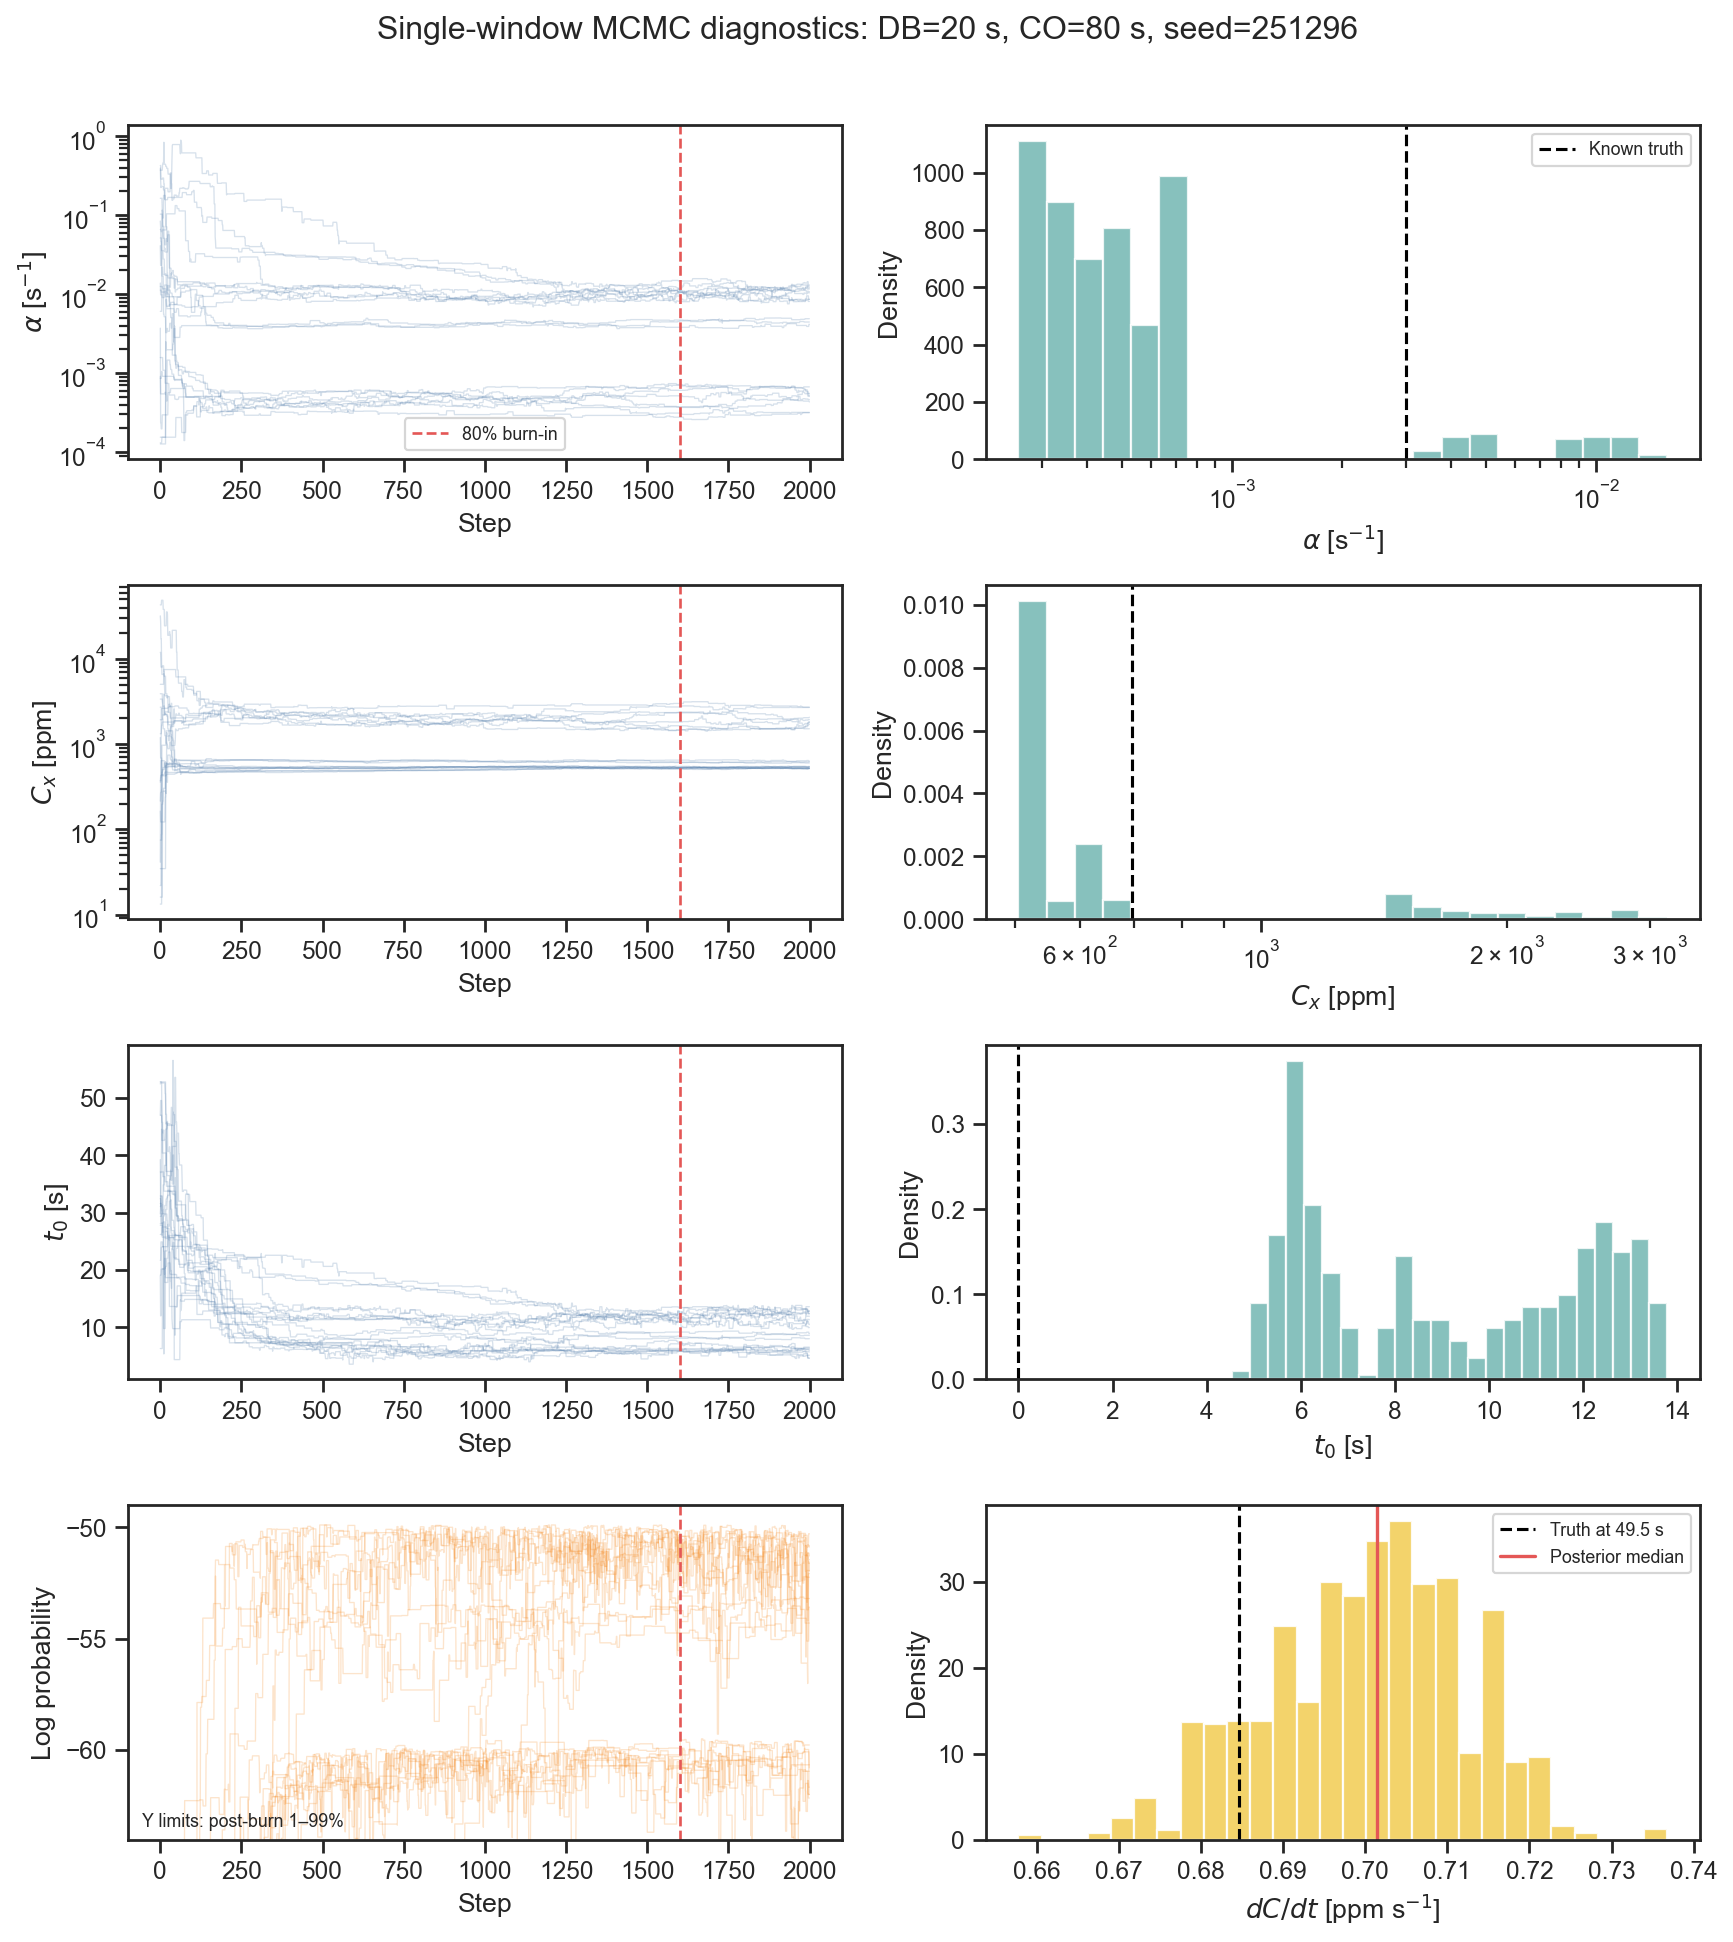

Saved figures/02_single_window_mcmc.png


In [7]:
diagnostic_figure_path = FIGURE_DIR / "02_single_window_mcmc.png"
fig, axes = plt.subplots(4, 2, figsize=(11, 12), dpi=160)
burn_step = int(N_MCMC_STEPS * BURN_IN_FRACTION)
parameter_specs = [
    (0, r"$\alpha$ [s$^{-1}$]", TRUTH["alpha"]),
    (1, r"$C_x$ [ppm]", TRUTH["cx"]),
    (2, r"$t_0$ [s]", TRUTH["t0"]),
]
for row, (column, label, truth_value) in enumerate(parameter_specs):
    axes[row, 0].plot(chain[:, :, column], color="#4c78a8", alpha=0.22, linewidth=0.6)
    axes[row, 0].axvline(
        burn_step, color="#e45756", linestyle="--", linewidth=1.2,
        label=f"{BURN_IN_FRACTION:.0%} burn-in",
    )
    axes[row, 0].set(xlabel="Step", ylabel=label)
    if column in {0, 1}:
        axes[row, 0].set_yscale("log")
    if row == 0:
        axes[row, 0].legend(fontsize=8)

    parameter_values = retained_samples[:, column]
    if column in {0, 1}:
        positive_values = parameter_values[parameter_values > 0]
        histogram_bins = np.logspace(
            np.log10(positive_values.min()), np.log10(positive_values.max()), 24
        )
    else:
        histogram_bins = 24
    axes[row, 1].hist(
        parameter_values, bins=histogram_bins, color="#72b7b2", alpha=0.85, density=True
    )
    axes[row, 1].axvline(
        truth_value, color="black", linestyle="--", linewidth=1.4, label="Known truth"
    )
    axes[row, 1].set(xlabel=label, ylabel="Density")
    if column in {0, 1}:
        axes[row, 1].set_xscale("log")
    if row == 0:
        axes[row, 1].legend(fontsize=8)

axes[3, 0].plot(logprob_chain, color="#f58518", alpha=0.22, linewidth=0.6)
axes[3, 0].axvline(burn_step, color="#e45756", linestyle="--", linewidth=1.2)
axes[3, 0].set(xlabel="Step", ylabel="Log probability")
finite_postburn_logprob = logprob_chain[burn_step:][np.isfinite(logprob_chain[burn_step:])]
if finite_postburn_logprob.size == 0:
    raise RuntimeError("No finite post-burn log-probability values are available for plotting.")
logprob_low, logprob_high = np.quantile(finite_postburn_logprob, [0.01, 0.99])
logprob_padding = max(1e-9, 0.08 * (logprob_high - logprob_low))
axes[3, 0].set_ylim(logprob_low - logprob_padding, logprob_high + logprob_padding)
axes[3, 0].text(
    0.02, 0.04, "Y limits: post-burn 1–99%", transform=axes[3, 0].transAxes, fontsize=8
)

axes[3, 1].hist(resampled_dcdt, bins=28, color="#f2cf5b", alpha=0.9, density=True)
axes[3, 1].axvline(
    truth_dcdt_example, color="black", linestyle="--", linewidth=1.4,
    label=f"Truth at {window_midpoint_s:g} s",
)
axes[3, 1].axvline(
    np.median(resampled_dcdt), color="#e45756", linewidth=1.5, label="Posterior median"
)
axes[3, 1].set(xlabel=r"$dC/dt$ [ppm s$^{-1}$]", ylabel="Density")
axes[3, 1].legend(fontsize=8)

fig.suptitle(
    f"Single-window MCMC diagnostics: DB={EXAMPLE_DEADBAND} s, "
    f"CO={EXAMPLE_CUTOFF} s, seed={MCMC_SEED}",
    y=1.01,
)
fig.tight_layout()
fig.savefig(diagnostic_figure_path, dpi=220, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved {diagnostic_figure_path.relative_to(EXAMPLE_DIR)}")


### Focused posterior histogram and the one-sigma-equivalent interval

The highlighted band is the configured worked-window posterior's central 16th–84th percentile interval. It is called **1σ-equivalent** because a Gaussian places about 68% of its mass between those percentiles; it is not computed as mean ± standard deviation and, because of the improper \(t_0\) prior, it is not a valid Bayesian credible interval.

This focused histogram uses the directly seeded worked-window run above. The later grid advances the random-number sequence through earlier grid windows, so an otherwise identical DB/CO grid cell can have different short-chain quantiles.


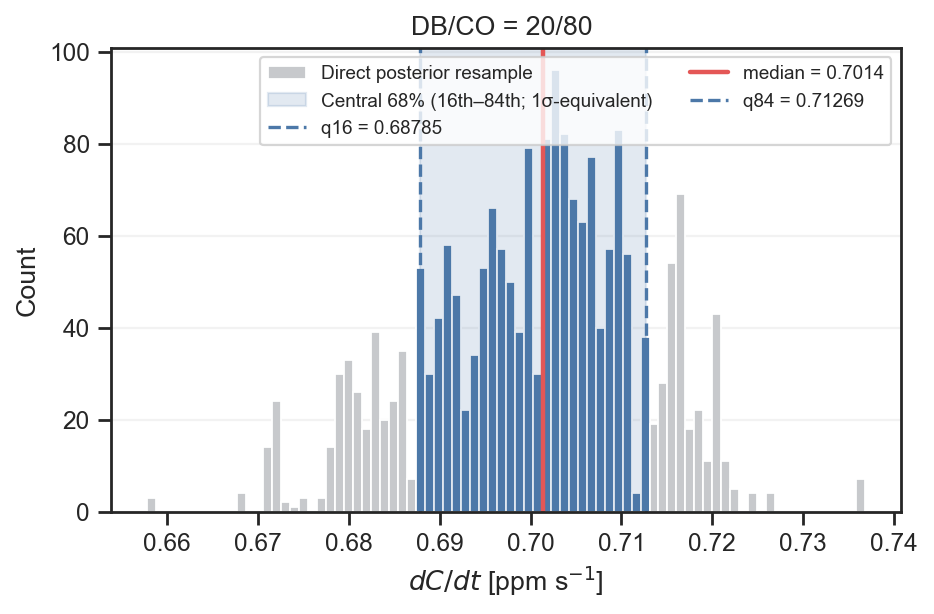

Saved figures/05_worked_window_sigma1.png


In [8]:
sigma_figure_path = FIGURE_DIR / "05_worked_window_sigma1.png"
fig, ax = plt.subplots(figsize=(6, 4), dpi=160)
# from the true +- a percentage of the truth, instead of quantiles, to show the truth is within the 1-sigma range
filter_resampled_dcdt = resampled_dcdt[
    (resampled_dcdt >= truth_dcdt_example * 0.9) & (resampled_dcdt <= truth_dcdt_example * 1.1)
]
counts, bin_edges, patches = ax.hist(
    filter_resampled_dcdt,
    bins=80,
    color="#c7c9cc",
    edgecolor="white",
    linewidth=0.8,
    label="Direct posterior resample",
)
for patch, left_edge, right_edge in zip(patches, bin_edges[:-1], bin_edges[1:]):
    bin_center = 0.5 * (left_edge + right_edge)
    if direct_q16 <= bin_center <= direct_q84:
        patch.set_facecolor("#4c78a8")

ax.axvspan(
    direct_q16, direct_q84, color="#4c78a8", alpha=0.16,
    label="Central 68% (16th–84th; 1σ-equivalent)",
)
ax.axvline(
    direct_q16, color="#4c78a8", linestyle="--", linewidth=1.5,
    label=f"q16 = {direct_q16:.5g}",
)
ax.axvline(
    direct_q50, color="#e45756", linewidth=2.0,
    label=f"median = {direct_q50:.5g}",
)
ax.axvline(
    direct_q84, color="#4c78a8", linestyle="--", linewidth=1.5,
    label=f"q84 = {direct_q84:.5g}",
)
# ax.axvline(
#     truth_dcdt_example, color="black", linestyle=":", linewidth=2.0,
#     label=f"ideal source at {window_midpoint_s:g} s = {truth_dcdt_example:.5g}",
# )
ax.set(
    xlabel=rf"$dC/dt$ [ppm s$^{{-1}}$]",
    ylabel="Count",
    title=(
        f"DB/CO = {EXAMPLE_DEADBAND}/{EXAMPLE_CUTOFF} "
        
    ),
)
# ax.set_xlim((0.5,0.7))
ax.legend(fontsize=8.5, frameon=True, ncols=2)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(sigma_figure_path, dpi=220, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved {sigma_figure_path.relative_to(EXAMPLE_DIR)}")


## 4. Scan the configured deadband/cutoff grid and select a Pareto compromise

`FCS.run_MC` performs the same MCMC calculation on the final sensor trace for every configured valid slice. The coordinates are generated by the package from `GRID_WINDOW_WALK`, `GRID_MIN_WINDOW_SIZE`, the deadband range, and the optional maximum cutoff. A candidate is valid only when `cutoff - deadband >= GRID_MIN_WINDOW_SIZE`.

Cutoff is exclusive. The coordinates represent seconds here only because the data are contiguous at the required 1 Hz sampling rate.

For each finite grid cell, the package defines

\[
U=q_{0.84}(dC/dt)-q_{0.16}(dC/dt),\qquad
L=-\operatorname{median}(\log p).
\]

It min-max normalizes \(U\) and \(L\) separately, retains non-dominated cells while minimizing both, and selects the Pareto point nearest the normalized origin. Because the implemented log likelihood is a sum over observations, \(L\) scales with window length. It is a length-dependent package objective, not a per-observation goodness-of-fit statistic.


In [9]:
np.random.seed(MCMC_SEED)
fcs = FCS(df_data=canonical, chamber_id=MEASUREMENT_ID)
fcs.settings(
    moving_window=True,
    window_walk=GRID_WINDOW_WALK,
    min_window_size=GRID_MIN_WINDOW_SIZE,
    min_deadband=GRID_MIN_DEADBAND,
    max_deadband=GRID_MAX_DEADBAND,
    max_cutoff=(
        float(canonical["timedelta"].max())
        if GRID_MAX_CUTOFF is None
        else float(GRID_MAX_CUTOFF)
    ),
)
grid_result = fcs.run_MC(
    n=MEASUREMENT_ID,
    n_MC=N_MCMC_STEPS,
    metadata=metadata,
    sensor_precision=SENSOR_PRECISION_PPM,
)[MEASUREMENT_ID]

grid_ds = xr.Dataset(
    data_vars={
        name: (("cutoff", "deadband", "MC"), np.asarray(values, dtype=float))
        for name, values in grid_result.items()
        if name not in {"cutoff", "deadband", "MC"}
    },
    coords={
        "cutoff": np.asarray(grid_result["cutoff"], dtype=int),
        "deadband": np.asarray(grid_result["deadband"], dtype=int),
        "MC": np.asarray(grid_result["MC"], dtype=int),
    },
    attrs={
        "sensor_precision_ppm": SENSOR_PRECISION_PPM,
        "sampling_interval_s": SAMPLE_INTERVAL_S,
        "cutoff_is_exclusive": True,
        "window_walk": GRID_WINDOW_WALK,
        "minimum_window_size": GRID_MIN_WINDOW_SIZE,
    },
)

deadband_coordinates = grid_ds["deadband"].values
cutoff_coordinates = grid_ds["cutoff"].values
candidate_grid = (
    cutoff_coordinates[:, None] - deadband_coordinates[None, :] >= GRID_MIN_WINDOW_SIZE
)
candidate_window_count = int(candidate_grid.sum())
finite_grid = np.isfinite(grid_ds["dcdt(HM)"].median("MC"))
finite_window_count = int(finite_grid.sum())
if candidate_window_count < 1:
    raise RuntimeError("FCS generated no candidate windows from the configured grid.")
if finite_window_count < 1:
    raise RuntimeError(
        "No configured grid window produced a finite MCMC result. "
        "Try longer windows, a different grid, or more suitable source settings."
    )

pareto = Pareto(dsMC=grid_ds)
with np.errstate(divide="ignore", invalid="ignore"):
    normalized_u, normalized_l, flat_u, flat_l = pareto.prepare_metrics()
pareto_indices = pareto.find_pareto_front(
    flat_u, flat_l, maximize_x=False, maximize_y=False
)
if len(pareto_indices) == 0:
    raise RuntimeError(
        "No finite non-dominated Pareto front was found for the configured grid."
    )
pareto_coords = pareto.get_coords_pareto(pareto_indices)
best_cutoff_index, best_deadband_index = pareto.get_best_from_pareto(
    pareto_indices=pareto_indices,
    metric_x=normalized_u,
    metric_y=normalized_l,
)
best_cutoff = int(cutoff_coordinates[best_cutoff_index])
best_deadband = int(deadband_coordinates[best_deadband_index])

pareto_table = pd.DataFrame(
    {
        "deadband_s": deadband_coordinates[pareto_coords[1]],
        "cutoff_s": cutoff_coordinates[pareto_coords[0]],
        "uncertainty_U": pareto.uncertaintyRange.values[pareto_coords],
        "negative_median_logprob_L": pareto.logprob.values[pareto_coords],
    }
).sort_values("uncertainty_U")

# Only compare arbitrary windows that are present and finite in this grid.
compatible_arbitrary_configs = []
skipped_arbitrary_configs = []
for config in ARBITRARY_CONFIGS:
    reason = None
    if config["deadband"] not in deadband_coordinates:
        reason = "deadband is not a configured grid coordinate"
    elif config["cutoff"] not in cutoff_coordinates:
        reason = "cutoff is not a configured grid coordinate"
    else:
        db_index = int(np.flatnonzero(deadband_coordinates == config["deadband"])[0])
        co_index = int(np.flatnonzero(cutoff_coordinates == config["cutoff"])[0])
        if not bool(finite_grid.values[co_index, db_index]):
            reason = "the grid fit is invalid or non-finite"
    if reason is None:
        compatible_arbitrary_configs.append(config)
    else:
        skipped_arbitrary_configs.append({**config, "reason": reason})
        print(
            f"Skipping {config['label']} (DB={config['deadband']}, CO={config['cutoff']}): "
            f"{reason}."
        )

print(f"Grid dimensions: {dict(grid_ds.sizes)}")
print(f"Candidate windows: {candidate_window_count}")
print(f"Finite fitted windows: {finite_window_count}")
print(f"Pareto points: {len(pareto_indices)}")
print(f"Selected compromise: deadband={best_deadband} s, cutoff={best_cutoff} s")
display(pareto_table.reset_index(drop=True))


Grid dimensions: {'cutoff': 12, 'deadband': 6, 'MC': 2000}
Candidate windows: 57
Finite fitted windows: 57
Pareto points: 11
Selected compromise: deadband=30 s, cutoff=90 s


,deadband_s,cutoff_s,uncertainty_U,negative_median_logprob_L
0,0,150,0.006029,161.717333
1,0,140,0.006864,154.849226
2,20,150,0.008063,127.015119
3,10,140,0.009479,125.712283
4,20,120,0.010185,104.111465
5,10,100,0.012938,83.935428
6,10,90,0.016500,70.067672
7,10,80,0.028628,62.059493
8,30,90,0.031189,57.179304
9,20,80,0.063799,52.714998


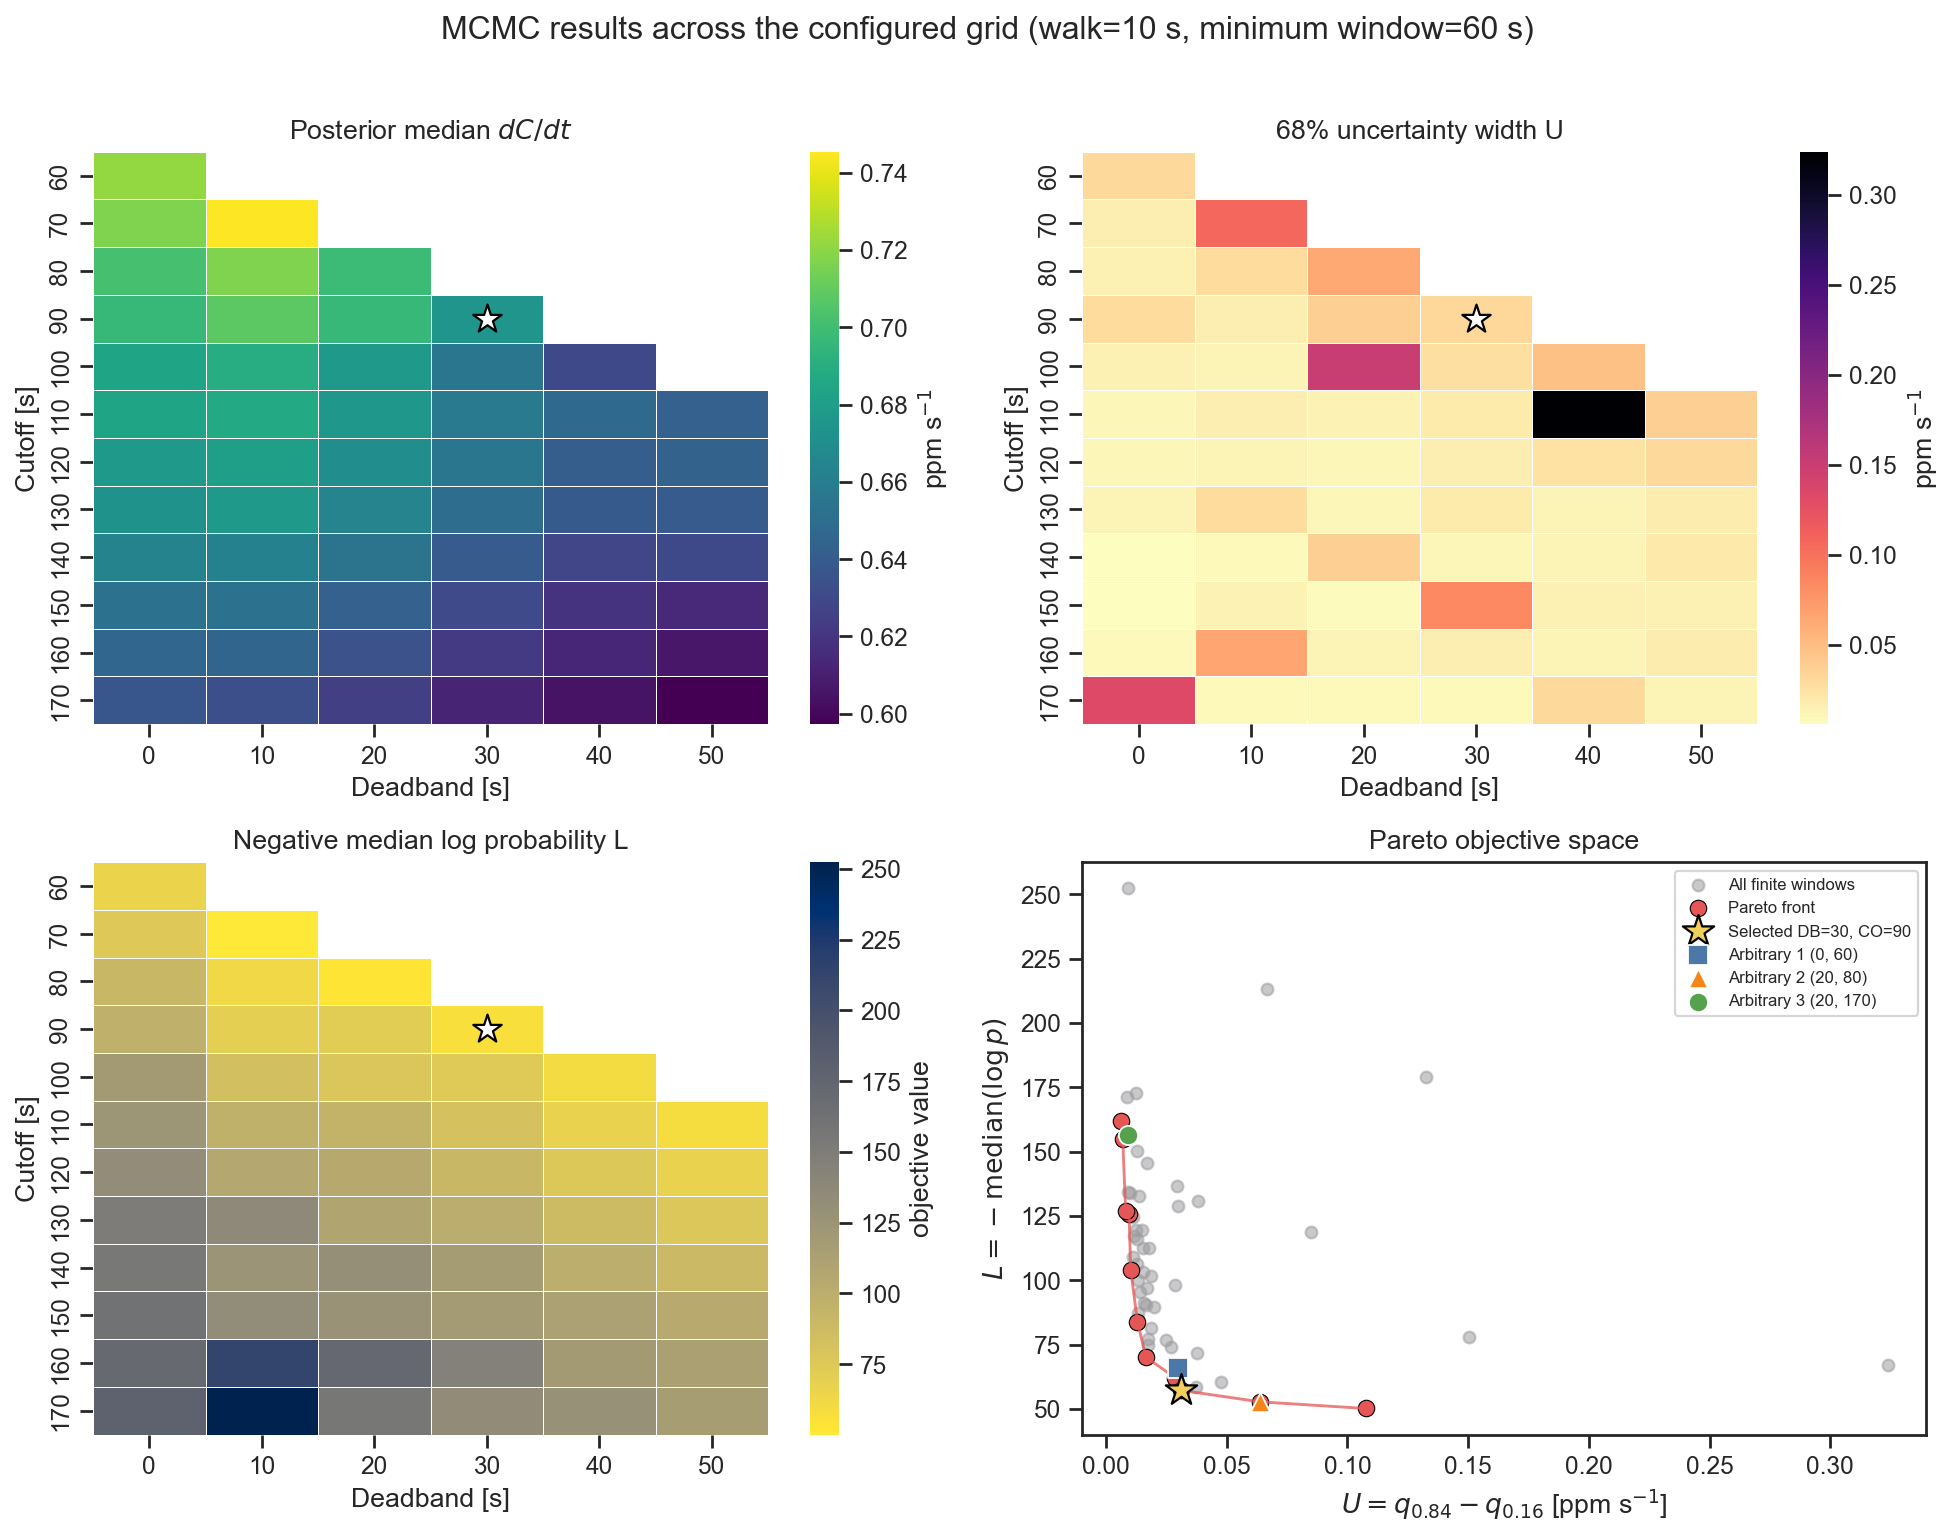

Saved figures/03_window_grid_pareto.png


In [10]:
grid_figure_path = FIGURE_DIR / "03_window_grid_pareto.png"
uncertainty_grid = pareto.uncertaintyRange.values
negative_logprob_grid = pareto.logprob.values
median_grid = grid_ds["dcdt(HM)"].median("MC").values

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.5), dpi=160)
heatmap_specs = [
    (axes[0, 0], median_grid, r"Posterior median $dC/dt$", r"ppm s$^{-1}$", "viridis"),
    (axes[0, 1], uncertainty_grid, "68% uncertainty width U", r"ppm s$^{-1}$", "magma_r"),
    (axes[1, 0], negative_logprob_grid, "Negative median log probability L", "objective value", "cividis_r"),
]

for ax, values, title, cbar_label, cmap in heatmap_specs:
    frame = pd.DataFrame(values, index=cutoff_coordinates, columns=deadband_coordinates)
    sns.heatmap(
        frame, mask=~np.isfinite(frame), cmap=cmap, ax=ax,
        cbar_kws={"label": cbar_label}, linewidths=0.25, linecolor="white",
    )
    ax.scatter(
        best_deadband_index + 0.5, best_cutoff_index + 0.5,
        marker="*", s=180, color="white", edgecolor="black", linewidth=1.0, zorder=10,
    )
    ax.set(xlabel="Deadband [s]", ylabel="Cutoff [s]", title=title)

pareto_ax = axes[1, 1]
finite_objectives = np.isfinite(uncertainty_grid) & np.isfinite(negative_logprob_grid)
pareto_ax.scatter(
    uncertainty_grid[finite_objectives], negative_logprob_grid[finite_objectives],
    s=28, color="#9d9da1", alpha=0.55, label="All finite windows",
)
front_u = uncertainty_grid[pareto_coords]
front_l = negative_logprob_grid[pareto_coords]
sort_front = np.argsort(front_u)
pareto_ax.plot(
    front_u[sort_front], front_l[sort_front], color="#e45756", linewidth=1.3, alpha=0.75
)
pareto_ax.scatter(
    front_u, front_l, s=55, color="#e45756", edgecolor="black", linewidth=0.5,
    label="Pareto front",
)
pareto_ax.scatter(
    uncertainty_grid[best_cutoff_index, best_deadband_index],
    negative_logprob_grid[best_cutoff_index, best_deadband_index],
    marker="*", s=220, color="#f2cf5b", edgecolor="black", linewidth=1.0,
    label=f"Selected DB={best_deadband}, CO={best_cutoff}", zorder=12,
)
for config in compatible_arbitrary_configs:
    db_index = int(np.flatnonzero(deadband_coordinates == config["deadband"])[0])
    co_index = int(np.flatnonzero(cutoff_coordinates == config["cutoff"])[0])
    pareto_ax.scatter(
        uncertainty_grid[co_index, db_index], negative_logprob_grid[co_index, db_index],
        marker=config["marker"], s=75, color=config["color"], edgecolor="white",
        linewidth=0.8,
        label=f"{config['label']} ({config['deadband']}, {config['cutoff']})",
        zorder=11,
    )
pareto_ax.set(
    xlabel=r"$U=q_{0.84}-q_{0.16}$ [ppm s$^{-1}$]",
    ylabel=r"$L=-\mathrm{median}(\log p)$",
    title="Pareto objective space",
)
pareto_ax.legend(fontsize=7.5, frameon=True)

fig.suptitle(
    f"MCMC results across the configured grid (walk={GRID_WINDOW_WALK} s, "
    f"minimum window={GRID_MIN_WINDOW_SIZE} s)",
    y=1.01,
)
fig.tight_layout()
fig.savefig(grid_figure_path, dpi=220, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved {grid_figure_path.relative_to(EXAMPLE_DIR)}")


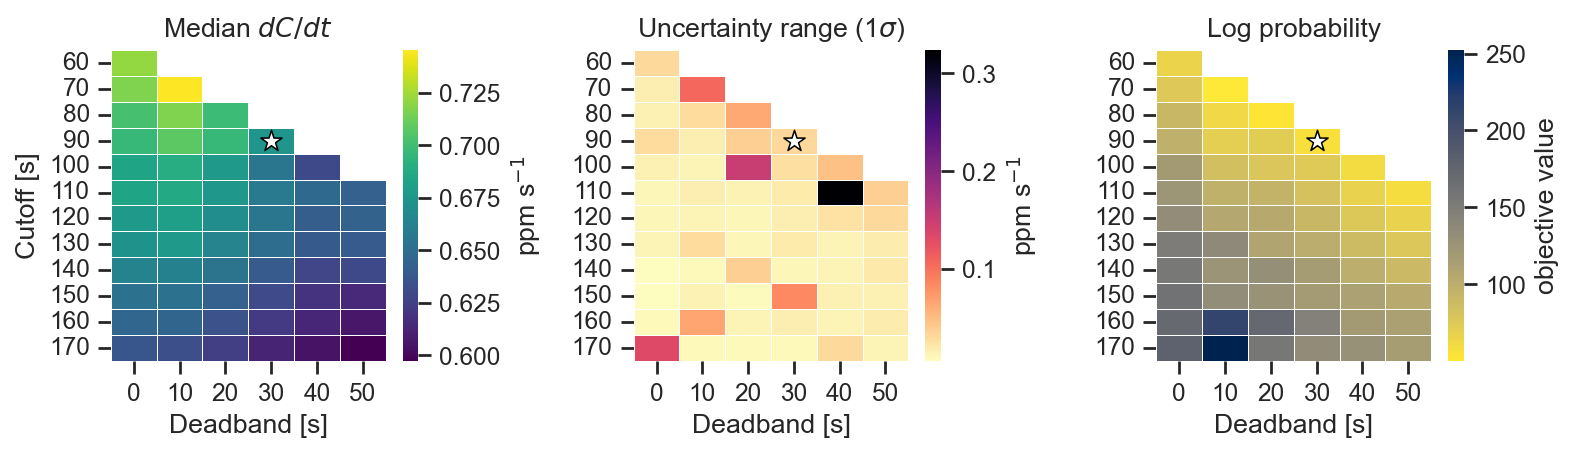

Saved figures/07_window_grid_matrices.png


In [92]:
# Three matrix panels with only a small star marking the Pareto optimum.
matrix_only_figure_path = FIGURE_DIR / "07_window_grid_matrices.png"
matrix_only_specs = [
    (median_grid, r"Median $dC/dt$", r"ppm s$^{-1}$", "viridis"),
    (uncertainty_grid, "Uncertainty range (1$\sigma$)", r"ppm s$^{-1}$", "magma_r"),
    (
        negative_logprob_grid,
        "Log probability",
        "objective value",
        "cividis_r",
    ),
]

fig, axes = plt.subplots(1, 3, figsize=(10, 3), dpi=160)
for panel_index, (ax, values, title, cbar_label, cmap) in enumerate(
    zip(axes, *zip(*matrix_only_specs))
):
    matrix_frame = pd.DataFrame(
        values,
        index=cutoff_coordinates,
        columns=deadband_coordinates,
    )
    sns.heatmap(
        matrix_frame,
        mask=~np.isfinite(matrix_frame),
        cmap=cmap,
        ax=ax,
        cbar_kws={"label": cbar_label},
        linewidths=0.25,
        linecolor="white",
    )
    ax.scatter(
        best_deadband_index + 0.5,
        best_cutoff_index + 0.5,
        marker="*",
        s=100,
        color="white",
        edgecolor="black",
        linewidth=0.7,
        zorder=10,
    )
    ax.set(
        xlabel="Deadband [s]",
        ylabel="Cutoff [s]" if panel_index == 0 else "",
        title=title,
    )

# fig.suptitle(
#     # f"MCMC matrices across the configured grid (walk={GRID_WINDOW_WALK} s, "
#     # f"minimum window={GRID_MIN_WINDOW_SIZE} s)",
#     # "MCMC matrices",
#     y=1.02,
# )
fig.tight_layout()
fig.savefig(matrix_only_figure_path, dpi=300, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved {matrix_only_figure_path.relative_to(EXAMPLE_DIR)}")

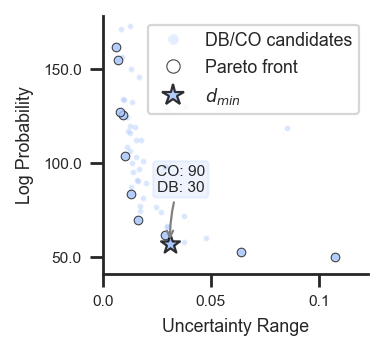

Saved figures/06_pareto_paper_style.png


In [12]:
# Paper-style Pareto plot matching 03_pareto_lowcost_vs_commercial.ipynb.
from matplotlib.lines import Line2D

paper_style_pareto_figure_path = FIGURE_DIR / "06_pareto_paper_style.png"
CM = 1 / 2.54
paper_lowcost_color = sns.color_palette("coolwarm", n_colors=2)[0]

paper_all_u = np.asarray(uncertainty_grid, dtype=float).ravel()
paper_all_l = np.asarray(negative_logprob_grid, dtype=float).ravel()
paper_finite = np.isfinite(paper_all_u) & np.isfinite(paper_all_l)
paper_front_u = np.asarray(front_u, dtype=float).ravel()
paper_front_l = np.asarray(front_l, dtype=float).ravel()
paper_front_finite = np.isfinite(paper_front_u) & np.isfinite(paper_front_l)
if not paper_finite.any() or not paper_front_finite.any():
    raise RuntimeError("No finite Pareto objective values are available for the paper-style plot.")

paper_front_u = paper_front_u[paper_front_finite]
paper_front_l = paper_front_l[paper_front_finite]
paper_x_span = float(np.ptp(paper_front_u)) or max(float(np.max(paper_front_u)), 1.0)
paper_y_span = float(np.ptp(paper_front_l)) or max(abs(float(np.max(paper_front_l))), 1.0)
paper_x_limits = (
    max(0.0, float(np.min(paper_front_u)) - 0.08 * paper_x_span),
    float(np.max(paper_front_u)) + 0.15 * paper_x_span,
)
paper_y_limits = (
    float(np.min(paper_front_l)) - 0.08 * paper_y_span,
    float(np.max(paper_front_l)) + 0.15 * paper_y_span,
)

paper_best_u = float(uncertainty_grid[best_cutoff_index, best_deadband_index])
paper_best_l = float(negative_logprob_grid[best_cutoff_index, best_deadband_index])

fig, ax = plt.subplots(figsize=(6.5 * CM, 6 * CM), dpi=160)
ax.scatter(
    paper_all_u[paper_finite],
    paper_all_l[paper_finite],
    s=3,
    c=[paper_lowcost_color],
    alpha=0.3,
)
ax.scatter(
    paper_front_u,
    paper_front_l,
    s=15,
    c=[paper_lowcost_color],
    alpha=0.8,
    marker="o",
    edgecolors="k",
    linewidth=0.5,
    zorder=5,
)
ax.scatter(
    paper_best_u,
    paper_best_l,
    s=80,
    c=[paper_lowcost_color],
    alpha=0.9,
    marker="*",
    edgecolors="k",
    linewidth=1,
    zorder=10,
)

ax.set_xlim(paper_x_limits)
ax.set_ylim(paper_y_limits)
ax.set_xlabel("Uncertainty Range", fontsize=8)
ax.set_ylabel("Log Probability", fontsize=8)
# ax.set_title("Pareto front", fontsize=12)

paper_x_range = paper_x_limits[1] - paper_x_limits[0]
paper_y_range = paper_y_limits[1] - paper_y_limits[0]
paper_x_text = min(
    paper_x_limits[1] - 0.03 * paper_x_range,
    paper_best_u + 0.04 * paper_x_range,
)
paper_y_text = min(
    paper_y_limits[1] - 0.05 * paper_y_range,
    paper_best_l + 0.25 * paper_y_range,
)
ax.annotate(
    f"CO: {best_cutoff:.0f}\nDB: {best_deadband:.0f}",
    xy=(paper_best_u, paper_best_l),
    xytext=(paper_x_text, paper_y_text),
    fontsize=7,
    ha="center",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.2",
        facecolor=paper_lowcost_color,
        alpha=0.2,
        edgecolor=paper_lowcost_color,
    ),
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=0.1",
        color="grey",
        lw=1,
    ),
    zorder=15,
)

paper_legend_handles = [
    Line2D(
        [0], [0], marker="o", color="w", markerfacecolor=paper_lowcost_color,
        markersize=5, alpha=0.3, label="DB/CO candidates",
    ),
    Line2D(
        [0], [0], marker="o", color="w", markerfacecolor='white',
        markersize=6, markeredgecolor="k", markeredgewidth=0.5,
        alpha=0.8, label="Pareto front",
    ),
    Line2D(
        [0], [0], marker="*", color="w", markerfacecolor=paper_lowcost_color,
        markersize=10, markeredgecolor="k", markeredgewidth=1,
        alpha=0.9, label=r"$d_{min}$",
    ),
]
ax.legend(handles=paper_legend_handles, fontsize=8, frameon=True, loc="best")
#legend outside the axes
# ax.legend(handles=paper_legend_handles, fontsize=8, frameon=True, loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_xticklabels(ax.get_xticks(), fontsize=7)
ax.set_yticklabels(ax.get_yticks(), fontsize=7)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(paper_style_pareto_figure_path, dpi=160, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved {paper_style_pareto_figure_path.relative_to(EXAMPLE_DIR)}")

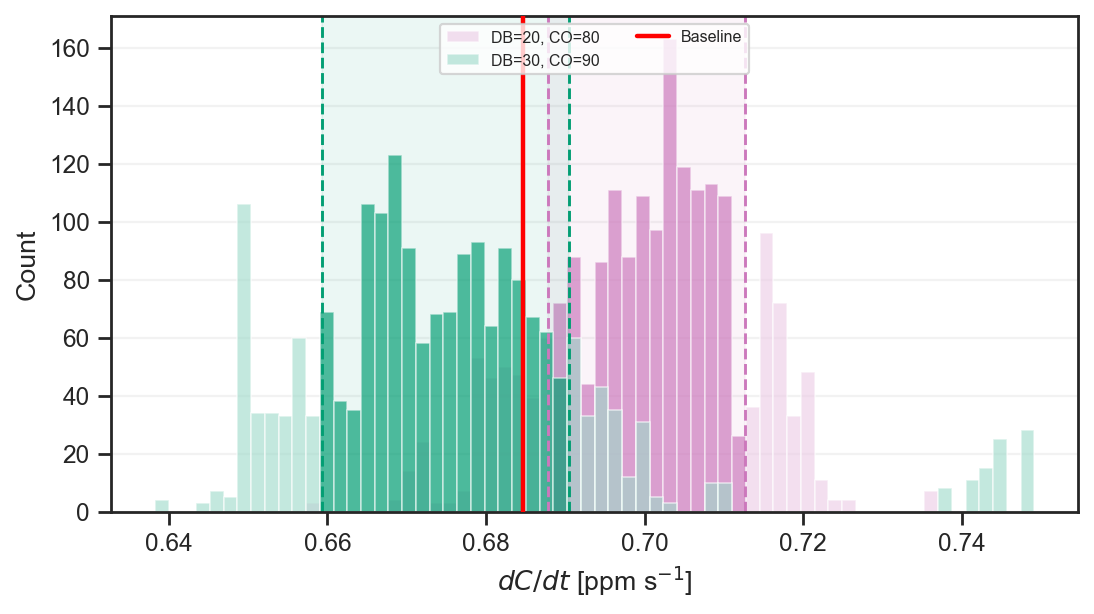

,window,deadband_s,cutoff_s,midpoint_s,q16,median,q84,ideal_truth
0,Configured worked window,20,80,49.5,0.68785,0.70140,0.71269,0.68462
1,Pareto-optimal window,30,90,59.5,0.65930,0.67446,0.69049,0.72586


Saved figures/08_selected_vs_optimal_histograms.png


In [84]:
# Overlap the configured worked-window and Pareto-optimal posterior histograms.
selected_optimal_histogram_path = FIGURE_DIR / "08_selected_vs_optimal_histograms.png"

optimal_dcdt_values = grid_ds["dcdt(HM)"].sel(
    deadband=best_deadband,
    cutoff=best_cutoff,
).values.astype(float)
optimal_dcdt_values = optimal_dcdt_values[np.isfinite(optimal_dcdt_values)]
if optimal_dcdt_values.size == 0:
    raise RuntimeError("The Pareto-optimal window has no finite dC/dt values to plot.")

optimal_window_times = canonical["timedelta"].to_numpy()[best_deadband:best_cutoff]
if len(optimal_window_times) == 0:
    raise RuntimeError("The Pareto-optimal DB/CO produces an empty data window.")
optimal_midpoint_s = float(np.median(optimal_window_times))
optimal_truth_dcdt = float(hm_model_dcdt(
    t0=TRUTH["t0"],
    c0=TRUTH["c0"],
    a=TRUTH["alpha"],
    cx=TRUTH["cx"],
    # t=optimal_midpoint_s,
    t=30
))
optimal_q16, optimal_q50, optimal_q84 = np.quantile(
    optimal_dcdt_values,
    [0.16, 0.50, 0.84],
)
assert np.isfinite([
    optimal_q16, optimal_q50, optimal_q84, optimal_truth_dcdt
]).all()
assert optimal_q16 <= optimal_q50 <= optimal_q84

# Window-comparison colors are deliberately separate from the sensor-type palette.
window_histogram_palette = sns.color_palette("colorblind", n_colors=8)
configured_window_color = window_histogram_palette[4]  # purple
pareto_window_color = window_histogram_palette[2]      # green


def blend_histogram_color_with_white(color, white_fraction=0.62):
    color = np.asarray(color, dtype=float)
    return tuple((1 - white_fraction) * color + white_fraction * np.ones(3))


histogram_series = [
    {
        "values": np.asarray(resampled_dcdt, dtype=float),
        "q16": direct_q16,
        "median": direct_q50,
        "q84": direct_q84,
        "truth": truth_dcdt_example,
        "midpoint": window_midpoint_s,
        "deadband": EXAMPLE_DEADBAND,
        "cutoff": EXAMPLE_CUTOFF,
        "label": "Configured worked window",
        "color": configured_window_color,
        "light_color": blend_histogram_color_with_white(configured_window_color),
        "median_linestyle": "-",
        "truth_linestyle": ":",
        "source": "direct chain",
    },
    {
        "values": optimal_dcdt_values,
        "q16": optimal_q16,
        "median": optimal_q50,
        "q84": optimal_q84,
        "truth": optimal_truth_dcdt,
        "midpoint": optimal_midpoint_s,
        "deadband": best_deadband,
        "cutoff": best_cutoff,
        "label": "Pareto-optimal window",
        "color": pareto_window_color,
        "light_color": blend_histogram_color_with_white(pareto_window_color),
        "median_linestyle": "--",
        "truth_linestyle": "-.",
        "source": "grid chain",
    },
]

combined_histogram_values = np.concatenate([
    series["values"] for series in histogram_series
])
shared_bin_edges = np.histogram_bin_edges(combined_histogram_values, bins=64)

fig, ax = plt.subplots(figsize=(7, 4), dpi=160)
for series in histogram_series:
    
    series_name = (
        f"DB={series['deadband']}, CO={series['cutoff']} "
        # f"({series['source']})"
    )
    counts, bin_edges, patches = ax.hist(
        series["values"],
        bins=shared_bin_edges,
        color=series["light_color"],
        edgecolor="white",
        linewidth=0.7,
        alpha=0.62,
        label=series_name,
    )
    for patch, left_edge, right_edge in zip(patches, bin_edges[:-1], bin_edges[1:]):
        bin_center = 0.5 * (left_edge + right_edge)
        if series["q16"] <= bin_center <= series["q84"]:
            patch.set_facecolor(series["color"])
            patch.set_alpha(0.68)

    ax.axvspan(
        series["q16"],
        series["q84"],
        color=series["color"],
        alpha=0.08,
        # label=(
        #     # f"{series['label']} (1$\sigma$) "
        #     # f"[{series['q16']:.5g}, {series['q84']:.5g}]"
        # ),
    )
    ax.axvline(
        series["q16"],
        color=series["color"],
        linestyle="--",
        linewidth=1.3,
    )
    ax.axvline(
        series["q84"],
        color=series["color"],
        linestyle="--",
        linewidth=1.3,
    )
    # ax.axvline(
    #     series["median"],
    #     color="#e45756",
    #     linestyle=series["median_linestyle"],
    #     linewidth=2.2,
    #     label=f"{series['label']} median = {series['median']:.5g}",
    # )
    # ax.axvline(
    #     series["truth"],
    #     color="black",
    #     linestyle=series["truth_linestyle"],
    #     linewidth=2.0,
    #     zorder=7,
    #     label=(
    #         f"{series['label']} ideal at {series['midpoint']:g} s "
    #         f"= {series['truth']:.5g}"
    #     ),
    # )

ax.axvline(
    truth_dcdt_example,
    color="red",
    linestyle="-",
    linewidth=2.0,
    zorder=5,
    label=(
        # f"Configured worked window ideal at {window_midpoint_s:g} s "
        # f"= {truth_dcdt_example:.5g}"
        f"Baseline"
    ),
)

ax.set(
    xlabel=r"$dC/dt$ [ppm s$^{-1}$]",
    ylabel="Count",
    # title="Configured and Pareto-optimal posterior derivative distributions",
)
ax.grid(axis="y", alpha=0.25)
ax.legend(fontsize=7.2, frameon=True, ncols=2, loc="upper center")
fig.tight_layout()
fig.savefig(selected_optimal_histogram_path, dpi=300, bbox_inches="tight")
display(fig)
plt.close(fig)

selected_optimal_summary = pd.DataFrame(
    {
        "window": [series["label"] for series in histogram_series],
        "deadband_s": [series["deadband"] for series in histogram_series],
        "cutoff_s": [series["cutoff"] for series in histogram_series],
        "midpoint_s": [series["midpoint"] for series in histogram_series],
        "q16": [series["q16"] for series in histogram_series],
        "median": [series["median"] for series in histogram_series],
        "q84": [series["q84"] for series in histogram_series],
        "ideal_truth": [series["truth"] for series in histogram_series],
    }
)
display(selected_optimal_summary.round(5))
print(f"Saved {selected_optimal_histogram_path.relative_to(EXAMPLE_DIR)}")

## 5. Compare compatible arbitrary windows with the ideal source and Pareto selection

For each slice, MCMC reports \(dC/dt\) at that slice's median timestamp. Because the ideal H–M derivative changes with time, each package output is compared with the ideal source derivative at **its own** midpoint:

\[
\mathrm{relative\ error}=100\,
\frac{\operatorname{median}(dC/dt)-dC/dt_{\rm ideal}(t_{mid})}
{|dC/dt_{\rm ideal}(t_{mid})|}.
\]

The resulting error includes configured chamber/analyzer transport, stochastic mixing, response filtering, precision noise, and fitting behavior. Arbitrary configurations absent from the current grid or having a non-finite fit are skipped with an explicit message. Relative-to-Pareto comparisons use uncertainty-width ratios and changes in the package's length-dependent \(L\) objective.


In [14]:
pressure_kpa = ENVIRONMENT["pressure_pa"] / 1000.0
saturated_vapor_pressure_kpa = float(
    calculate_saturated_vapor_pressure(ENVIRONMENT["temperature_c"])
)
water_vapor_mmol_mol = float(mole_fraction_water_vapor(
    ENVIRONMENT["temperature_c"], ENVIRONMENT["humidity_percent"], pressure_kpa
))
flux_per_dcdt = float(soilgasflux(
    volume=CHAMBER["volume_cm3"],
    area=CHAMBER["area_cm2"],
    p0=pressure_kpa,
    w0=water_vapor_mmol_mol,
    t0=ENVIRONMENT["temperature_c"],
    dcdt=1.0,
))

comparison_configs = [
    {
        "label": "Pareto selected", "deadband": best_deadband, "cutoff": best_cutoff,
        "color": "#b279a2", "marker": "*",
    },
    *compatible_arbitrary_configs,
]
records = []
normalized_posteriors = {}
for config in comparison_configs:
    values = grid_ds["dcdt(HM)"].sel(
        deadband=config["deadband"], cutoff=config["cutoff"]
    ).values.astype(float)
    logprob_values = grid_ds["logprob(HM)"].sel(
        deadband=config["deadband"], cutoff=config["cutoff"]
    ).values.astype(float)
    if not np.isfinite(values).any():
        raise RuntimeError(f"No finite MCMC values for {config['label']}.")
    window_times = canonical["timedelta"].to_numpy()[
        config["deadband"]:config["cutoff"]
    ]
    if len(window_times) < 1:
        raise RuntimeError(f"{config['label']} has an empty data slice.")
    midpoint_s = float(np.median(window_times))
    truth_dcdt = float(hm_model_dcdt(
        t0=TRUTH["t0"], c0=TRUTH["c0"], a=TRUTH["alpha"],
        cx=TRUTH["cx"], t=midpoint_s,
    ))
    q16, median, q84 = np.nanquantile(values, [0.16, 0.50, 0.84])
    uncertainty_width = q84 - q16
    if np.isclose(truth_dcdt, 0.0):
        relative_error = np.nan
        normalized_posteriors[config["label"]] = np.full_like(values, np.nan)
    else:
        relative_error = 100.0 * (median - truth_dcdt) / abs(truth_dcdt)
        normalized_posteriors[config["label"]] = values / truth_dcdt
    negative_median_logprob = -float(np.nanmedian(logprob_values))
    records.append(
        {
            "configuration": config["label"],
            "deadband_s": config["deadband"],
            "cutoff_s": config["cutoff"],
            "midpoint_s": midpoint_s,
            "q16_dcdt": q16,
            "median_dcdt": median,
            "q84_dcdt": q84,
            "truth_dcdt": truth_dcdt,
            "relative_error_percent": relative_error,
            "uncertainty_width": uncertainty_width,
            "negative_median_logprob": negative_median_logprob,
            "median_flux_umol_m2_s": median * flux_per_dcdt,
            "truth_flux_umol_m2_s": truth_dcdt * flux_per_dcdt,
        }
    )

comparison_df = pd.DataFrame(records)
core_summary_columns = [
    "q16_dcdt", "median_dcdt", "q84_dcdt", "truth_dcdt",
    "uncertainty_width", "negative_median_logprob",
]
assert np.isfinite(comparison_df[core_summary_columns].to_numpy()).all()
assert (
    (comparison_df["q16_dcdt"] <= comparison_df["median_dcdt"])
    & (comparison_df["median_dcdt"] <= comparison_df["q84_dcdt"])
).all()

pareto_reference = comparison_df.iloc[0]
if np.isclose(pareto_reference["uncertainty_width"], 0.0):
    comparison_df["uncertainty_width_ratio_vs_pareto"] = np.nan
else:
    comparison_df["uncertainty_width_ratio_vs_pareto"] = (
        comparison_df["uncertainty_width"] / pareto_reference["uncertainty_width"]
    )
comparison_df["negative_logprob_delta_vs_pareto"] = (
    comparison_df["negative_median_logprob"]
    - pareto_reference["negative_median_logprob"]
)
comparison_df["absolute_error_delta_pp_vs_pareto"] = (
    comparison_df["relative_error_percent"].abs()
    - abs(pareto_reference["relative_error_percent"])
)

display(comparison_df.round(5))
print(f"Saturated vapor pressure: {saturated_vapor_pressure_kpa:.6g} kPa")
print(f"Water-vapor mole fraction W0: {water_vapor_mmol_mol:.6g} mmol mol^-1")
print(f"Flux conversion factor: {flux_per_dcdt:.6g} µmol m^-2 s^-1 per ppm s^-1")


,configuration,deadband_s,cutoff_s,midpoint_s,q16_dcdt,median_dcdt,q84_dcdt,truth_dcdt,relative_error_percent,uncertainty_width,negative_median_logprob,median_flux_umol_m2_s,truth_flux_umol_m2_s,uncertainty_width_ratio_vs_pareto,negative_logprob_delta_vs_pareto,absolute_error_delta_pp_vs_pareto
0,Pareto selected,30,90,59.5,0.65930,0.67446,0.69049,0.66439,1.51686,0.03119,57.17930,5.38839,5.30788,1.00000,0.00000,0.00000
1,Arbitrary 1,0,60,29.5,0.70511,0.72154,0.73494,0.72695,-0.74432,0.02983,65.91401,5.76452,5.80774,0.95653,8.73470,-0.77254
2,Arbitrary 2,20,80,49.5,0.68529,0.69847,0.74909,0.68462,2.02262,0.06380,52.71500,5.58016,5.46953,2.04557,-4.46431,0.50576
3,Arbitrary 3,20,170,94.5,0.62103,0.62460,0.63005,0.59816,4.41983,0.00902,156.28725,4.99003,4.77881,0.28909,99.10795,2.90297


Saturated vapor pressure: 2.33834 kPa
Water-vapor mole fraction W0: 16.5337 mmol mol^-1
Flux conversion factor: 7.98915 µmol m^-2 s^-1 per ppm s^-1


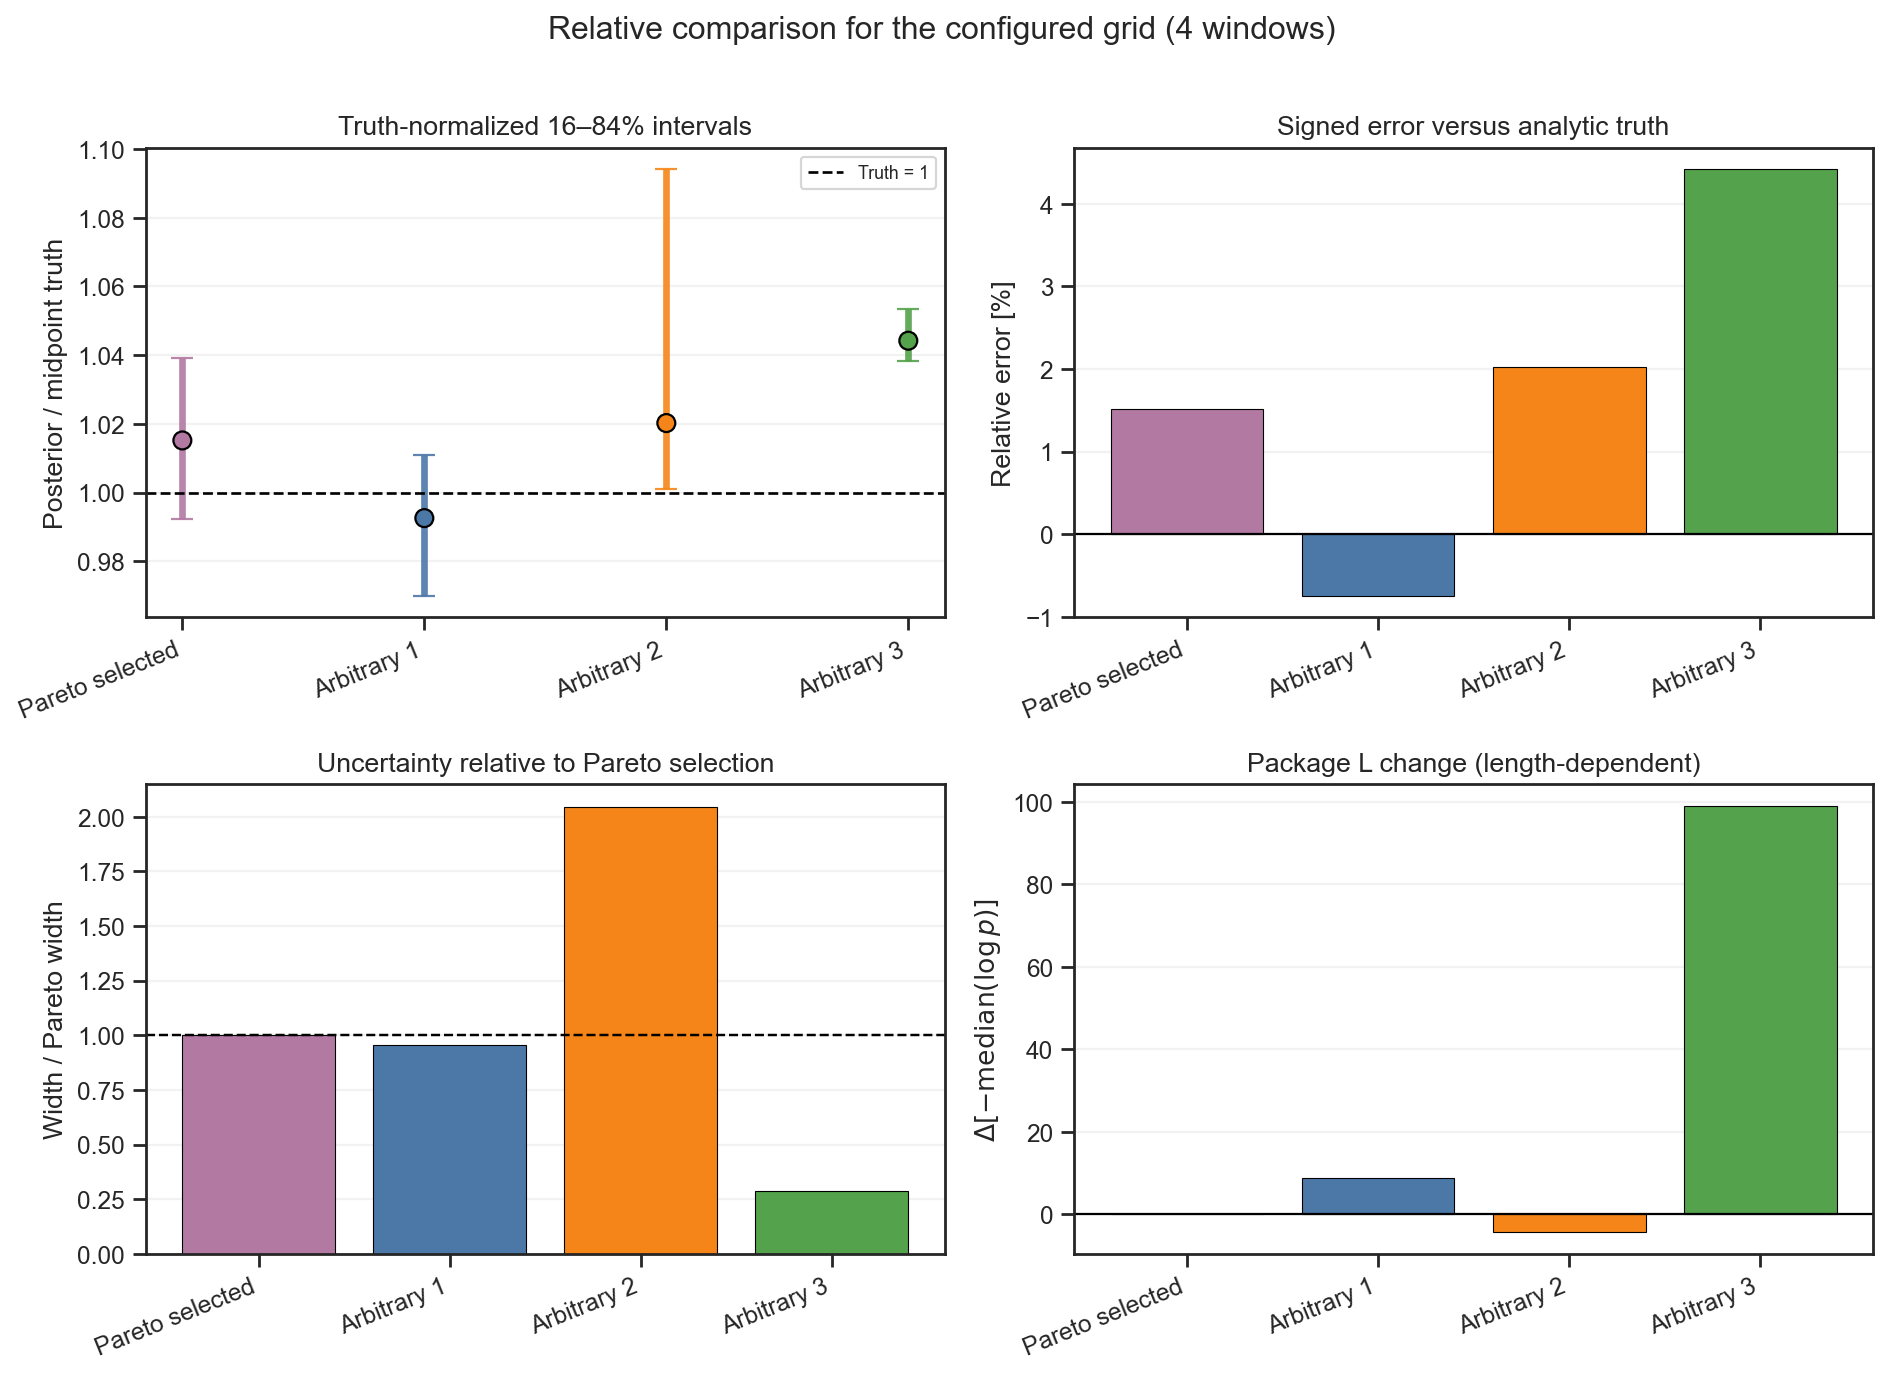

Saved figures/04_relative_comparison.png


In [15]:
comparison_figure_path = FIGURE_DIR / "04_relative_comparison.png"
labels = comparison_df["configuration"].tolist()
colors = [config["color"] for config in comparison_configs]
x = np.arange(len(labels))

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), dpi=160)

normalized_q16 = comparison_df["q16_dcdt"] / comparison_df["truth_dcdt"]
normalized_median = comparison_df["median_dcdt"] / comparison_df["truth_dcdt"]
normalized_q84 = comparison_df["q84_dcdt"] / comparison_df["truth_dcdt"]
for index in range(len(labels)):
    if np.isfinite([
        normalized_q16.iloc[index], normalized_median.iloc[index], normalized_q84.iloc[index]
    ]).all():
        axes[0, 0].errorbar(
            [x[index]], [normalized_median.iloc[index]],
            yerr=np.array([
                [normalized_median.iloc[index] - normalized_q16.iloc[index]],
                [normalized_q84.iloc[index] - normalized_median.iloc[index]],
            ]),
            fmt="none", ecolor=colors[index], elinewidth=3, capsize=5, alpha=0.9,
        )
axes[0, 0].scatter(x, normalized_median, color=colors, edgecolor="black", s=65, zorder=5)
axes[0, 0].axhline(1.0, color="black", linestyle="--", linewidth=1.2, label="Truth = 1")
axes[0, 0].set(ylabel="Posterior / midpoint truth", title="Truth-normalized 16–84% intervals")
axes[0, 0].legend(fontsize=8)

axes[0, 1].bar(
    x, comparison_df["relative_error_percent"], color=colors, edgecolor="black", linewidth=0.5
)
axes[0, 1].axhline(0.0, color="black", linewidth=1)
axes[0, 1].set(ylabel="Relative error [%]", title="Signed error versus analytic truth")

axes[1, 0].bar(
    x, comparison_df["uncertainty_width_ratio_vs_pareto"],
    color=colors, edgecolor="black", linewidth=0.5,
)
axes[1, 0].axhline(1.0, color="black", linestyle="--", linewidth=1.1)
axes[1, 0].set(ylabel="Width / Pareto width", title="Uncertainty relative to Pareto selection")

axes[1, 1].bar(
    x, comparison_df["negative_logprob_delta_vs_pareto"],
    color=colors, edgecolor="black", linewidth=0.5,
)
axes[1, 1].axhline(0.0, color="black", linewidth=1)
axes[1, 1].set(
    ylabel=r"$\Delta[-\mathrm{median}(\log p)]$",
    title="Package L change (length-dependent)",
)

for ax in axes.flat:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=22, ha="right")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    f"Relative comparison for the configured grid ({len(comparison_configs)} windows)", y=1.01
)
fig.tight_layout()
fig.savefig(comparison_figure_path, dpi=220, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved {comparison_figure_path.relative_to(EXAMPLE_DIR)}")


## 6. Water-vapor correction and flux conversion

With temperature in °C and pressure in kPa, Buck's equation and the water-vapor mole fraction are

\[
e_s(T)=0.61121\exp\left[\left(18.678-\frac{T}{234.5}\right)
\frac{T}{257.14+T}\right],\qquad
W_0=1000\frac{e_s(T)\,RH/100}{P_0}.
\]

The package converts a concentration rate to soil-gas flux using

\[
F=\frac{10VP_0(1-W_0/1000)}{RA(T+273.15)}\frac{dC}{dt},
\]

where \(V\) is in cm³, \(A\) in cm², \(P_0\) in kPa, and \(R=8.31446261815324\ \mathrm{J\,K^{-1}\,mol^{-1}}\). The result is in µmol m⁻² s⁻¹.

### Fidelity notes

- The raw trace is produced by the configured chamber/pump/analyzer simulation before MCMC processing.
- `sensor_accuracy` is recorded by `Simulate_Sensor` but is not applied to measurement values; configured sensor precision noise is applied.
- Raw pressure is used for flux conversion, while `Simulate_Sensor` currently uses its own default internal pressure.
- Sensor precision is used twice: once to generate measurement noise and again as the MCMC likelihood's `yerr`.
- The MCMC derivative is evaluated at each window's median timestamp. The non-MCMC package path instead averages the derivative over the window.
- The current prior does not bound \(t_0\), even though the deterministic fit and initial walker positions do. This makes the implemented posterior improper, so its quantiles are not valid Bayesian uncertainty statements.
- Resampling with replacement does not create additional independent posterior states.
- Pareto selection uses uncertainty and negative median log probability. The latter is summed across observations and therefore length-dependent; it is not a per-observation fit statistic.


In [16]:
expected_figures = [
    raw_figure_path,
    diagnostic_figure_path,
    sigma_figure_path,
    grid_figure_path,
    matrix_only_figure_path,
    paper_style_pareto_figure_path,
    selected_optimal_histogram_path,
    comparison_figure_path,
]
for path in expected_figures:
    assert path.exists() and path.stat().st_size > 0, f"Missing or empty figure: {path}"

assert len(expected_figures) == 8
assert RAW_CSV.exists() and RAW_CSV.stat().st_size > 0
assert np.array_equal(measured_co2_ppm, deterministic_rerun_co2_ppm)
assert np.array_equal(raw["co2_ppm"].to_numpy(), measured_co2_ppm)
assert list(canonical.columns) == CANONICAL_COLUMNS
assert len(canonical) == N_SAMPLES
assert not canonical.isna().any().any()
assert np.all(np.diff(canonical["timedelta"].to_numpy()) == SAMPLE_INTERVAL_S)
assert raw["sensor_response_time_s"].eq(SENSOR_SETTINGS["response_time"]).all()
assert raw["sensor_precision_ppm"].eq(SENSOR_PRECISION_PPM).all()
assert np.isfinite(internal_analyzer_co2_ppm).all()
assert np.isfinite(response_only_co2_ppm).all()
assert np.isfinite(measured_co2_ppm).all()

assert np.isclose(c0_manual, c0_package, rtol=0, atol=1e-10)
assert len(worked_terms_df) == EXAMPLE_CUTOFF - EXAMPLE_DEADBAND
assert np.isfinite(worked_terms_df.select_dtypes(include=[np.number]).to_numpy()).all()
assert np.allclose(worked_model_manual, worked_model_package, rtol=0, atol=1e-10)
assert np.allclose(worked_dcdt_manual, worked_dcdt_package, rtol=0, atol=1e-10)
assert np.isclose(manual_log_likelihood, package_log_likelihood, rtol=0, atol=1e-10)
assert np.isclose(midpoint_model_manual, midpoint_model_package, rtol=0, atol=1e-10)
assert np.isclose(midpoint_dcdt_manual, midpoint_dcdt_package, rtol=0, atol=1e-10)

assert len(retained_samples) > 0
assert len(resampled_dcdt) == N_MCMC_STEPS
assert np.isfinite([direct_q16, direct_q50, direct_q84]).all()
assert direct_q16 <= direct_q50 <= direct_q84
assert candidate_window_count >= finite_window_count >= 1
assert len(pareto_indices) > 0
assert np.isfinite(uncertainty_grid[best_cutoff_index, best_deadband_index])
assert np.isfinite(negative_logprob_grid[best_cutoff_index, best_deadband_index])

verification = pd.DataFrame(
    {
        "check": [
            "Target source change", "Final sensor value", "Worked DB/CO",
            "Worked observations", "Seed log likelihood", "Seed midpoint derivative",
            "Direct posterior interval", "Candidate grid windows", "Finite grid fits",
            "Pareto points", "Selected Pareto window", "Figures written",
        ],
        "result": [
            f"{TARGET_DELTA_PPM:.6g} ppm", f"{measured_co2_ppm[-1]:.6g} ppm",
            f"{EXAMPLE_DEADBAND}/{EXAMPLE_CUTOFF}", len(worked_terms_df),
            f"{manual_log_likelihood:.6g}", f"{midpoint_dcdt_manual:.6g} ppm s^-1",
            f"[{direct_q16:.6g}, {direct_q50:.6g}, {direct_q84:.6g}] ppm s^-1",
            candidate_window_count, finite_window_count, len(pareto_indices),
            f"DB={best_deadband}, CO={best_cutoff}", len(expected_figures),
        ],
    }
)
display(verification)
print("All configuration-derived notebook checks passed.")


,check,result
0,Target source change,110 ppm
1,Final sensor value,538.352 ppm
2,Worked DB/CO,20/80
3,Worked observations,60
4,Seed log likelihood,-49.8834
5,Seed midpoint derivative,0.697465 ppm s^-1
6,Direct posterior interval,"[0.687847, 0.701401, 0.712689] ppm s^-1"
7,Candidate grid windows,57
8,Finite grid fits,57
9,Pareto points,11


All configuration-derived notebook checks passed.
